In [1]:
# Install library yang diperlukan
!pip install openpyxl Sastrawi nltk wordcloud matplotlib seaborn pandas numpy scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from wordcloud import WordCloud
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Sastrawi (stemmer Bahasa Indonesia)
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Sklearn
from sklearn.feature_extraction.text import TfidfVectorizer

print('✅ Semua library berhasil di-import!')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


✅ Semua library berhasil di-import!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
# ── CATATAN: File Book1.xlsx sudah dimuat langsung dari path di bawah ──
# Tidak perlu upload manual. Pastikan file 'Book1.xlsx' ada di direktori yang sama
# dengan notebook ini, atau ubah path di cell berikutnya sesuai lokasi file.
print('✅ Langkah upload dilewati — menggunakan semua 1.158 data dari Book1.xlsx')

✅ Langkah upload dilewati — menggunakan semua 1.158 data dari Book1.xlsx


In [4]:
# Load dataset — MENGGUNAKAN SEMUA DATA (1.158 ulasan)
import os

# Coba beberapa kemungkinan path file
possible_paths = [
    'Book3.xlsx',
    '/content/Book3.xlsx',
    '/mnt/user-data/uploads/Book3.xlsx',
]

df = None
for path in possible_paths:
    if os.path.exists(path):
        df = pd.read_excel(path)
        print(f'✅ File ditemukan: {path}')
        break

if df is None:
    raise FileNotFoundError('Book3.xlsx tidak ditemukan! Pastikan file berada di direktori yang sama dengan notebook.')

print(f'Jumlah baris   : {df.shape[0]:,}  (seluruh data digunakan)')
print(f'Jumlah kolom   : {df.shape[1]}')
print(f'Nama kolom     : {list(df.columns)}')
print(f'Distribusi Rating:')
print(df["Rating"].value_counts().sort_index().to_string())


✅ File ditemukan: Book3.xlsx
Jumlah baris   : 5,407  (seluruh data digunakan)
Jumlah kolom   : 10
Nama kolom     : ['User Id', 'User Name', 'Comment', 'Rating', 'Detail Rating', 'Bought Products', 'Product Id', 'Product Name', 'Shop Id', 'Region']
Distribusi Rating:
Rating
1     591
2     615
3     936
4    1192
5    2073


In [5]:
# Tampilkan 5 baris pertama
df.head()

,User Id,User Name,Comment,Rating,Detail Rating,Bought Products,Product Id,Product Name,Shop Id,Region
0,239772482,l*****e,Desain:bagus\nBahan:cukup berkualitas\nKenyama...,4,product_quality: 4\nseller_service: 5\ndeliver...,Batik Indonesia Motif ABIMATA Kemeja Batik Sli...,28751481863,Batik Indonesia Motif ABIMATA Kemeja Batik Sli...,1088913202,ID
1,818084703,m*****5,Desain:keren dan moderen\nBahan:bagus\nTekstur...,4,product_quality: 4\nseller_service: 4\ndeliver...,Batik Indonesia Motif Abimata Kemeja Batik Sli...,28751481863,Batik Indonesia Motif ABIMATA Kemeja Batik Sli...,1088913202,ID
2,227253735,ari.irawan,Desain:batik dg desain yg bagus\nBahan:halus d...,4,product_quality: 4,Batik Indonesia Motif Abimata Kemeja Batik Sli...,28751481863,Batik Indonesia Motif ABIMATA Kemeja Batik Sli...,1088913202,ID
3,1316081004,garasibarbersop,Desain:bagus\nBahan:lmbut\nKenyamanan:passs di...,4,product_quality: 4,Batik Indonesia Motif Abimata Kemeja Batik Sli...,28751481863,Batik Indonesia Motif ABIMATA Kemeja Batik Sli...,1088913202,ID
4,311327546,b*****1,Desain:motif mewah dan hidup\nBahan:kualitas s...,4,product_quality: 4\nseller_service: 5\ndeliver...,Batik Indonesia Motif ABIMATA Kemeja Batik Sli...,28751481863,Batik Indonesia Motif ABIMATA Kemeja Batik Sli...,1088913202,ID


In [6]:
# Info tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5407 entries, 0 to 5406
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User Id          5407 non-null   int64 
 1   User Name        5345 non-null   object
 2   Comment          4567 non-null   object
 3   Rating           5407 non-null   int64 
 4   Detail Rating    5407 non-null   object
 5   Bought Products  5407 non-null   object
 6   Product Id       5407 non-null   int64 
 7   Product Name     5407 non-null   object
 8   Shop Id          5407 non-null   int64 
 9   Region           5400 non-null   object
dtypes: int64(4), object(6)
memory usage: 422.6+ KB


In [7]:
# Statistik deskriptif
df.describe(include='all')

,User Id,User Name,Comment,Rating,Detail Rating,Bought Products,Product Id,Product Name,Shop Id,Region
count,5.407000e+03,5345,4567,5407.000000,5407,5407,5.407000e+03,5407,5.407000e+03,5400
unique,NaN,4338,4347,NaN,282,2691,NaN,115,NaN,1
top,NaN,a*****a,Bahan:tipis,NaN,product_quality: 5\nseller_service: 5\ndeliver...,Atasan batik modern lengan panjang kimono full...,NaN,ATASAN BLOUSE BATIK LENGAN BALON UKURAN (M L X...,NaN,ID
freq,NaN,38,12,NaN,905,71,NaN,120,NaN,5400
mean,6.653118e+08,NaN,NaN,3.654892,NaN,NaN,2.142800e+10,NaN,4.707738e+08,NaN
std,8.412203e+08,NaN,NaN,1.369832,NaN,NaN,1.320556e+10,NaN,4.644124e+08,NaN
min,1.149550e+05,NaN,NaN,1.000000,NaN,NaN,5.494744e+08,NaN,1.807740e+05,NaN
25%,1.461338e+08,NaN,NaN,3.000000,NaN,NaN,9.313848e+09,NaN,6.461113e+07,NaN
50%,4.159442e+08,NaN,NaN,4.000000,NaN,NaN,2.304942e+10,NaN,2.564890e+08,NaN
75%,1.037670e+09,NaN,NaN,5.000000,NaN,NaN,2.777472e+10,NaN,1.085538e+09,NaN


#4.3 EDA Exploratory Data Analisys



##4.3.1 Distribusi Rating

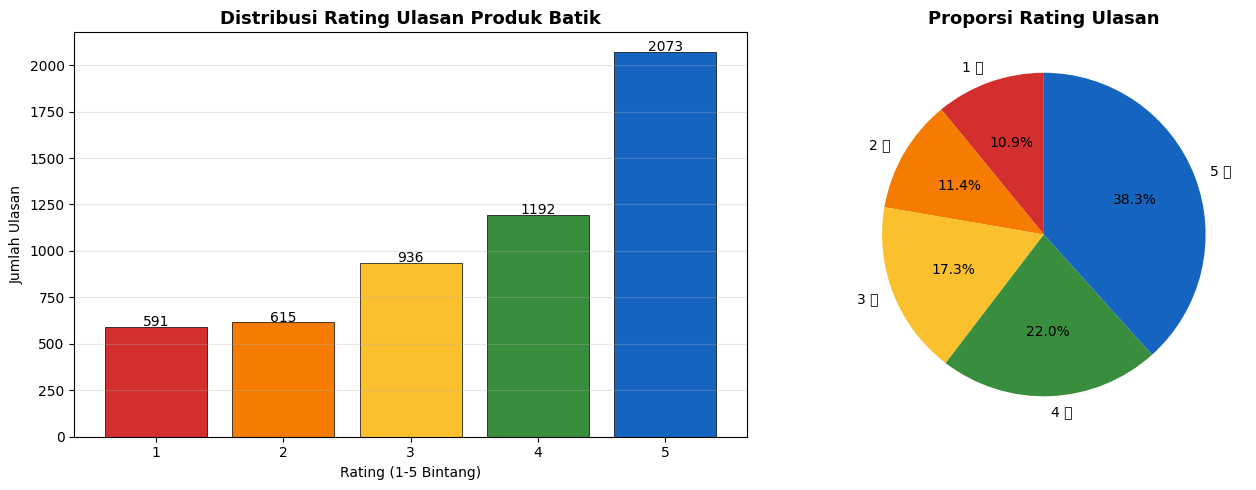

Rating
1     591
2     615
3     936
4    1192
5    2073
Name: count, dtype: int64


In [8]:
# Distribusi rating keseluruhan
rating_counts = df['Rating'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#d32f2f', '#f57c00', '#fbc02d', '#388e3c', '#1565c0']
axes[0].bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Distribusi Rating Ulasan Produk Batik', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rating (1-5 Bintang)')
axes[0].set_ylabel('Jumlah Ulasan')
for i, v in enumerate(rating_counts.values):
    axes[0].text(rating_counts.index[i], v + 5, str(v), ha='center', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(rating_counts.values, labels=[f'{r} ⭐' for r in rating_counts.index],
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Proporsi Rating Ulasan', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('distribusi_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print(rating_counts)

##4.3.2 Analisis Missing Value

In [9]:
# Cek missing value
print('=== Missing Values per Kolom ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

print(f'\nTotal ulasan kosong (Comment NaN): {df["Comment"].isnull().sum()}')
print(f'Total ulasan string kosong     : {(df["Comment"].astype(str).str.strip() == "").sum()}')

=== Missing Values per Kolom ===
           Missing Count  Missing (%)
User Name             62         1.15
Comment              840        15.54
Region                 7         0.13

Total ulasan kosong (Comment NaN): 840
Total ulasan string kosong     : 0


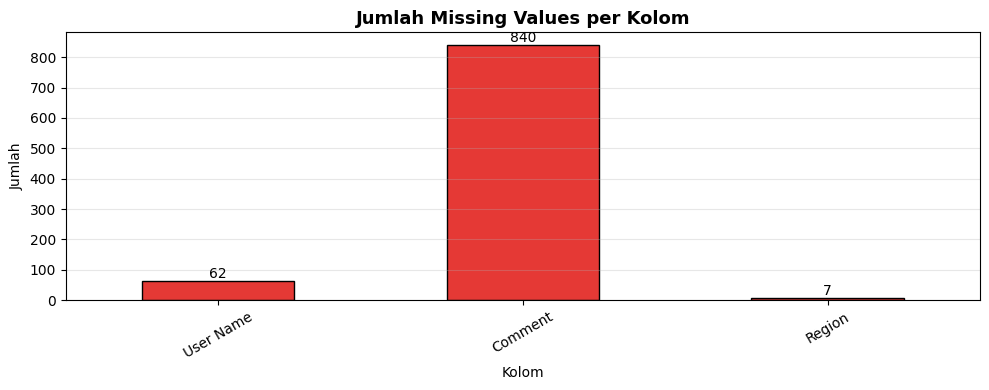

In [10]:
# Visualisasi missing value
fig, ax = plt.subplots(figsize=(10, 4))
missing_plot = missing[missing > 0]
if len(missing_plot) > 0:
    missing_plot.plot(kind='bar', color='#e53935', edgecolor='black', ax=ax)
    ax.set_title('Jumlah Missing Values per Kolom', fontsize=13, fontweight='bold')
    ax.set_ylabel('Jumlah')
    ax.set_xlabel('Kolom')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)
    for p in ax.patches:
        ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom')
else:
    ax.text(0.5, 0.5, 'Tidak ada missing value!', ha='center', va='center', fontsize=14)
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

##4.3.3 Analisis Produk Toko

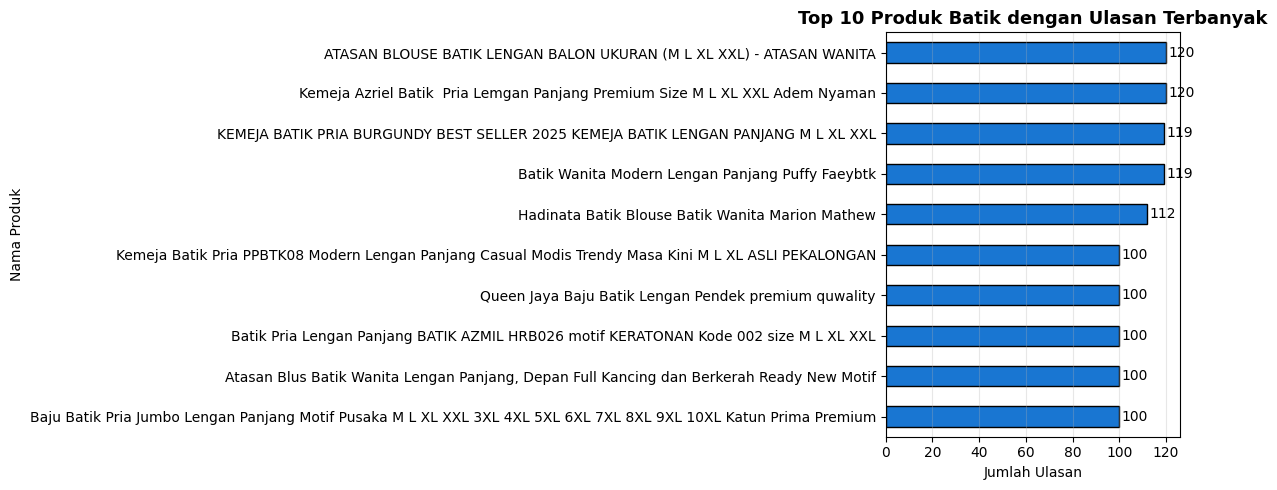

Jumlah produk unik: 115
Jumlah toko unik  : 58


In [11]:
# Top 10 produk terbanyak diulas
top_products = df['Product Name'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 5))
top_products.plot(kind='barh', color='#1976d2', edgecolor='black', ax=ax)
ax.set_title('Top 10 Produk Batik dengan Ulasan Terbanyak', fontsize=13, fontweight='bold')
ax.set_xlabel('Jumlah Ulasan')
ax.set_ylabel('Nama Produk')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
for p in ax.patches:
    ax.annotate(str(int(p.get_width())), (p.get_width() + 1, p.get_y() + p.get_height()/2),
                va='center')
plt.tight_layout()
plt.savefig('top_produk.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Jumlah produk unik: {df["Product Name"].nunique()}')
print(f'Jumlah toko unik  : {df["Shop Id"].nunique()}')

##4.3.4 Analisis Panjang Ulasan

=== Statistik Panjang Ulasan ===
       panjang_karakter  jumlah_kata
count           4567.00      4567.00
mean             124.66        17.96
std               92.02        14.24
min                1.00         1.00
25%               66.00         9.00
50%              105.00        15.00
75%              163.00        24.00
max             2346.00       303.00


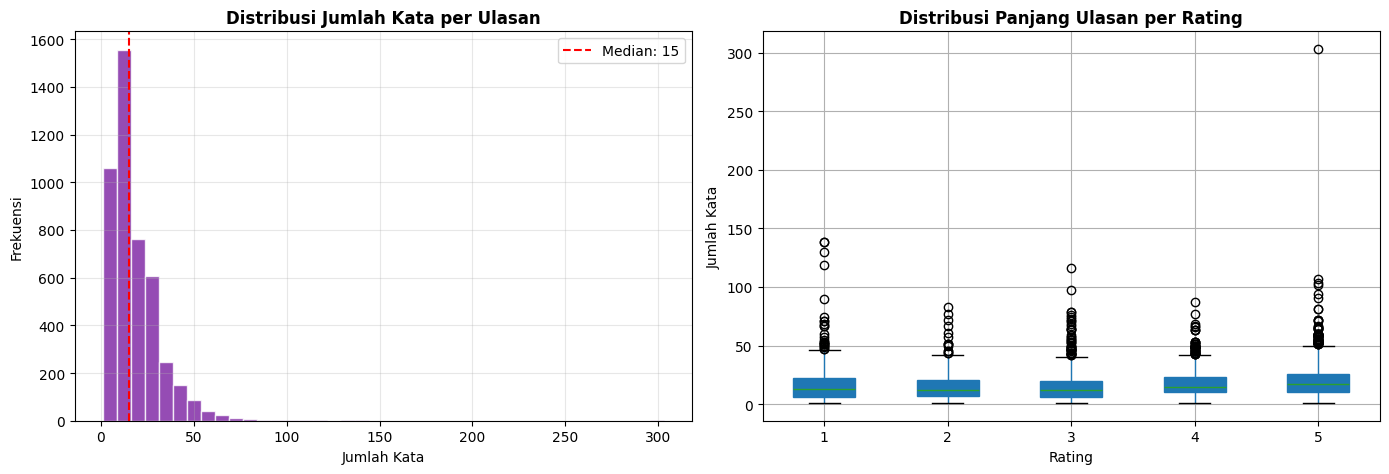

In [12]:
# Hitung panjang karakter dan kata per ulasan
df_ulasan = df[df['Comment'].notna() & (df['Comment'].astype(str).str.strip() != '')].copy()
df_ulasan['comment_str'] = df_ulasan['Comment'].astype(str)
df_ulasan['panjang_karakter'] = df_ulasan['comment_str'].str.len()
df_ulasan['jumlah_kata'] = df_ulasan['comment_str'].str.split().str.len()

print('=== Statistik Panjang Ulasan ===')
print(df_ulasan[['panjang_karakter', 'jumlah_kata']].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_ulasan['jumlah_kata'], bins=40, color='#7b1fa2', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribusi Jumlah Kata per Ulasan', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Kata')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(df_ulasan['jumlah_kata'].median(), color='red', linestyle='--',
                label=f'Median: {df_ulasan["jumlah_kata"].median():.0f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot jumlah kata per rating
df_ulasan.boxplot(column='jumlah_kata', by='Rating', ax=axes[1],
                  patch_artist=True, )
axes[1].set_title('Distribusi Panjang Ulasan per Rating', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Jumlah Kata')
plt.suptitle('')

plt.tight_layout()
plt.savefig('panjang_ulasan.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.3.5 Analisis Detail Rating

In [13]:
# Parse detail rating
def parse_detail_rating(detail_str):
    result = {}
    if pd.isna(detail_str):
        return result
    parts = str(detail_str).split()
    i = 0
    while i < len(parts):
        if ':' in parts[i]:
            key = parts[i].replace(':', '')
            if i+1 < len(parts):
                try:
                    result[key] = int(parts[i+1])
                    i += 2
                    continue
                except:
                    pass
        i += 1
    return result

detail_expanded = df['Detail Rating'].apply(parse_detail_rating).apply(pd.Series)
print('Kolom detail rating yang tersedia:')
print(detail_expanded.columns.tolist())
print()
print('Statistik rata-rata per dimensi:')
print(detail_expanded.mean().round(2))

Kolom detail rating yang tersedia:
['product_quality', 'seller_service', 'delivery_service', 'driver_service']

Statistik rata-rata per dimensi:
product_quality     3.66
seller_service      4.55
delivery_service    4.68
driver_service      4.83
dtype: float64


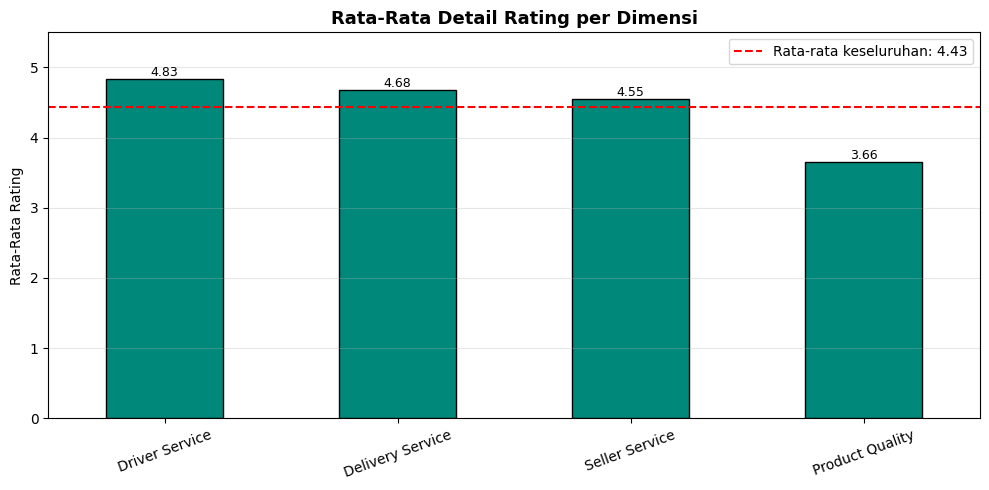

In [14]:
# Visualisasi rata-rata detail rating
avg_ratings = detail_expanded.mean().dropna().sort_values(ascending=False)
if len(avg_ratings) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    avg_ratings.plot(kind='bar', color='#00897b', edgecolor='black', ax=ax)
    ax.set_title('Rata-Rata Detail Rating per Dimensi', fontsize=13, fontweight='bold')
    ax.set_ylabel('Rata-Rata Rating')
    ax.set_ylim(0, 5.5)
    ax.set_xticklabels([col.replace('_', ' ').title() for col in avg_ratings.index], rotation=20)
    ax.axhline(y=avg_ratings.mean(), color='red', linestyle='--',
               label=f'Rata-rata keseluruhan: {avg_ratings.mean():.2f}')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig('detail_rating.png', dpi=150, bbox_inches='tight')
    plt.show()

##4.3.6 Analisis User Activity

Total user unik     : 5105
Rata-rata ulasan/user: 1.06
Max ulasan 1 user   : 4


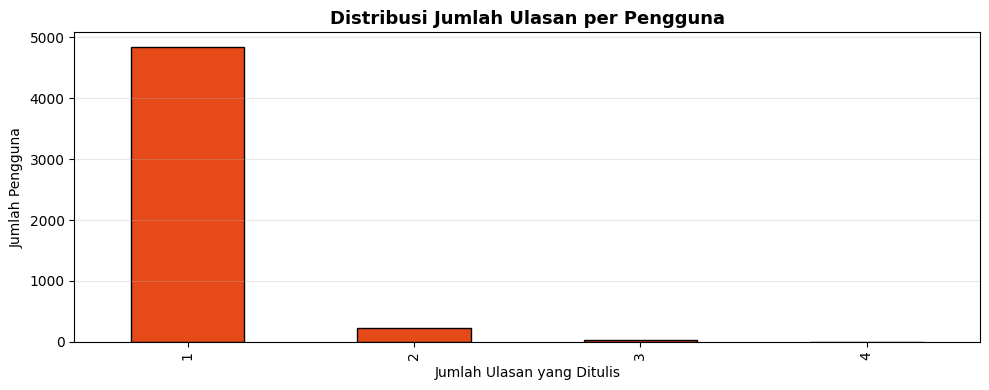

In [15]:
# Distribusi jumlah ulasan per user
user_counts = df.groupby('User Id').size()
print(f'Total user unik     : {user_counts.shape[0]}')
print(f'Rata-rata ulasan/user: {user_counts.mean():.2f}')
print(f'Max ulasan 1 user   : {user_counts.max()}')

fig, ax = plt.subplots(figsize=(10, 4))
user_activity = user_counts.value_counts().sort_index().head(15)
user_activity.plot(kind='bar', color='#e64a19', edgecolor='black', ax=ax)
ax.set_title('Distribusi Jumlah Ulasan per Pengguna', fontsize=13, fontweight='bold')
ax.set_xlabel('Jumlah Ulasan yang Ditulis')
ax.set_ylabel('Jumlah Pengguna')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('user_activity.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 4.4 Preprocessing Data

Tahapan preprocessing mengikuti metodologi penelitian pada BAB 3:
1. Data Cleaning (hapus duplikat, ulasan kosong)
2. Case Folding
3. Noise Removal
4. Normalisasi Kata (slang)
5. Tokenization
6. Stopword Removal
7. Stemming

## 4.4.1 Data Cleaning

In [16]:
print(f'Jumlah data awal         : {len(df)}')

# 1. Hapus baris dengan Comment kosong / NaN
df_clean = df.dropna(subset=['Comment']).copy()
df_clean = df_clean[df_clean['Comment'].astype(str).str.strip() != ''].copy()
print(f'Setelah hapus comment kosong: {len(df_clean)}')

# 2. Hapus duplikat (User + Comment sama)
df_clean = df_clean.drop_duplicates(subset=['User Id', 'Comment'])
print(f'Setelah hapus duplikat   : {len(df_clean)}')

# 3. Reset index
df_clean = df_clean.reset_index(drop=True)
df_clean['text'] = df_clean['Comment'].astype(str)
print(f'\nDataset siap diproses: {df_clean.shape}')

Jumlah data awal         : 5407
Setelah hapus comment kosong: 4567
Setelah hapus duplikat   : 4390

Dataset siap diproses: (4390, 11)


## 4.4.2 Case Folding

In [17]:
def case_folding(text):
    return text.lower()

df_clean['text'] = df_clean['text'].apply(case_folding)

# Contoh hasil
print('Contoh sebelum & sesudah Case Folding:')
sample = df_clean[['Comment', 'text']].head(3)
for i, row in sample.iterrows():
    print(f'  Asli   : {row["Comment"][:80]}')
    print(f'  Hasil  : {row["text"][:80]}')
    print()

Contoh sebelum & sesudah Case Folding:
  Asli   : Desain:bagus
Bahan:cukup berkualitas
Kenyamanan:ada furing nya

Buat BB 82 dan t
  Hasil  : desain:bagus
bahan:cukup berkualitas
kenyamanan:ada furing nya

buat bb 82 dan t

  Asli   : Desain:keren dan moderen
Bahan:bagus
Tekstur:lembut dan halus

Pengiriman cepat 
  Hasil  : desain:keren dan moderen
bahan:bagus
tekstur:lembut dan halus

pengiriman cepat 

  Asli   : Desain:batik dg desain yg bagus
Bahan:halus dan nyaman
Tekstur:sangat lembut dan
  Hasil  : desain:batik dg desain yg bagus
bahan:halus dan nyaman
tekstur:sangat lembut dan



##4.4.3 Noise Removal

In [18]:
def noise_removal(text):
    # Hapus URL
    text = re.sub(r'http\S+|www\S+', '', text)
    # Hapus mention (@) dan hashtag (#)
    text = re.sub(r'[@#]\S+', '', text)
    # Hapus karakter non-alfanumerik (kecuali spasi)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    # Hapus angka yang berdiri sendiri
    text = re.sub(r'\b\d+\b', '', text)
    # Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_clean['text'] = df_clean['text'].apply(noise_removal)

print('Contoh setelah Noise Removal:')
for i, row in df_clean[['Comment', 'text']].head(3).iterrows():
    print(f'  Asli  : {str(row["Comment"])[:80]}')
    print(f'  Hasil : {row["text"][:80]}')
    print()

Contoh setelah Noise Removal:
  Asli  : Desain:bagus
Bahan:cukup berkualitas
Kenyamanan:ada furing nya

Buat BB 82 dan t
  Hasil : desain bagus bahan cukup berkualitas kenyamanan ada furing nya buat bb dan tingg

  Asli  : Desain:keren dan moderen
Bahan:bagus
Tekstur:lembut dan halus

Pengiriman cepat 
  Hasil : desain keren dan moderen bahan bagus tekstur lembut dan halus pengiriman cepat d

  Asli  : Desain:batik dg desain yg bagus
Bahan:halus dan nyaman
Tekstur:sangat lembut dan
  Hasil : desain batik dg desain yg bagus bahan halus dan nyaman tekstur sangat lembut dan



##4.4.4 Normalisasi Kata (Kamus Slang Indonesia)

In [19]:
# Kamus normalisasi kata slang/tidak baku konteks ulasan batik
kamus_normalisasi = {
    # Kata umum tidak baku
    'gak': 'tidak', 'ga': 'tidak', 'ngga': 'tidak', 'nggak': 'tidak',
    'gk': 'tidak', 'tdk': 'tidak', 'tak': 'tidak', 'g': 'tidak',
    'tp': 'tapi', 'tpi': 'tapi', 'ttpi': 'tapi',
    'dg': 'dengan', 'dgn': 'dengan', 'sm': 'sama', 'sama2': 'sama-sama',
    'utk': 'untuk', 'tuk': 'untuk', 'buat': 'untuk',
    'sdh': 'sudah', 'udah': 'sudah', 'ud': 'sudah', 'dah': 'sudah',
    'blm': 'belum', 'blom': 'belum',
    'sy': 'saya', 'ak': 'saya', 'aq': 'saya', 'w': 'saya',
    'krn': 'karena', 'karna': 'karena',
    'yg': 'yang', 'yng': 'yang',
    'mksh': 'terima kasih', 'makasih': 'terima kasih', 'thanks': 'terima kasih',
    'thx': 'terima kasih', 'tks': 'terima kasih', 'ty': 'terima kasih',
    'ok': 'oke', 'okelah': 'oke',
    'bgs': 'bagus', 'bgus': 'bagus',
    'bhn': 'bahan', 'kain': 'bahan',
    'halus': 'halus', 'lembut': 'lembut',
    'adem': 'sejuk', 'ademm': 'sejuk',
    'rapi': 'rapi', 'rapih': 'rapi',
    'kualitas': 'kualitas', 'kwalitas': 'kualitas',
    'sesuai': 'sesuai', 'sesui': 'sesuai',
    'pesen': 'pesan', 'pesenan': 'pesanan',
    'pengiriman': 'pengiriman', 'delivery': 'pengiriman',
    'fast': 'cepat', 'gercep': 'cepat',
    'seller': 'penjual', 'toko': 'toko',
    'recommended': 'rekomendasi', 'recomend': 'rekomendasi', 'rekomen': 'rekomendasi',
    'mantap': 'bagus', 'mantul': 'bagus', 'mantep': 'bagus',
    'kece': 'bagus', 'keren': 'bagus',
    'puas': 'puas', 'puass': 'puas',
    'real': 'asli', 'realpic': 'foto asli', 'realpict': 'foto asli',
    'furing': 'furing', 'lapis': 'lapis',
    'slim': 'ramping', 'slimfit': 'ramping',
    'batik': 'batik', 'kemeja': 'kemeja', 'baju': 'baju',
    'motif': 'motif', 'desain': 'desain', 'design': 'desain',
    'warna': 'warna', 'corak': 'corak',
    'jahitan': 'jahitan', 'jahit': 'jahit',
    'ukuran': 'ukuran', 'size': 'ukuran',
    'pas': 'pas', 'cocok': 'cocok', 'sesuai': 'sesuai',
    'beli': 'beli', 'order': 'pesan', 'co': 'pesan',
    'packing': 'pengemasan', 'paket': 'paket',
    'sampai': 'tiba', 'nyampe': 'tiba', 'datang': 'tiba',
    'murah': 'murah', 'terjangkau': 'murah',
    'amanah': 'terpercaya',
    'next': 'lagi',
    'kondangan': 'pesta', 'acara': 'acara',
    'formal': 'formal', 'resmi': 'formal',
    'premium': 'premium',
    'kancingnya': 'kancing',
    'luntur': 'luntur',
    'awet': 'awet',
}

def normalisasi_kata(text):
    words = text.split()
    result = [kamus_normalisasi.get(word, word) for word in words]
    return ' '.join(result)

df_clean['text'] = df_clean['text'].apply(normalisasi_kata)

print(f'Ukuran kamus normalisasi: {len(kamus_normalisasi)} kata')
print('\nContoh normalisasi:')
for i, row in df_clean[['Comment', 'text']].head(3).iterrows():
    print(f'  Asli  : {str(row["Comment"])[:80]}')
    print(f'  Hasil : {row["text"][:80]}')
    print()

Ukuran kamus normalisasi: 113 kata

Contoh normalisasi:
  Asli  : Desain:bagus
Bahan:cukup berkualitas
Kenyamanan:ada furing nya

Buat BB 82 dan t
  Hasil : desain bagus bahan cukup berkualitas kenyamanan ada furing nya untuk bb dan ting

  Asli  : Desain:keren dan moderen
Bahan:bagus
Tekstur:lembut dan halus

Pengiriman cepat 
  Hasil : desain bagus dan moderen bahan bagus tekstur lembut dan halus pengiriman cepat d

  Asli  : Desain:batik dg desain yg bagus
Bahan:halus dan nyaman
Tekstur:sangat lembut dan
  Hasil : desain batik dengan desain yang bagus bahan halus dan nyaman tekstur sangat lemb



## 4.4.5 Tokenization

In [20]:
def tokenize(text):
    return text.split()  # Simple whitespace tokenizer
    # Alternatif: return word_tokenize(text)

df_clean['tokens'] = df_clean['text'].apply(tokenize)

print('Contoh hasil tokenization:')
for i in range(3):
    print(f'  [{i}] {df_clean["tokens"].iloc[i][:10]}...')

print(f'\nRata-rata token per ulasan: {df_clean["tokens"].str.len().mean():.1f}')

Contoh hasil tokenization:
  [0] ['desain', 'bagus', 'bahan', 'cukup', 'berkualitas', 'kenyamanan', 'ada', 'furing', 'nya', 'untuk']...
  [1] ['desain', 'bagus', 'dan', 'moderen', 'bahan', 'bagus', 'tekstur', 'lembut', 'dan', 'halus']...
  [2] ['desain', 'batik', 'dengan', 'desain', 'yang', 'bagus', 'bahan', 'halus', 'dan', 'nyaman']...

Rata-rata token per ulasan: 19.6


## 4.4.6 Stopword Removal

In [21]:
# Inisialisasi stopword factory Sastrawi + tambahan custom
sw_factory = StopWordRemoverFactory()
sastrawi_stopwords = set(sw_factory.get_stop_words())

# Stopword tambahan konteks ulasan e-commerce
custom_stopwords = {
    'ya', 'yaa', 'yaaa', 'sih', 'lah', 'deh', 'dong', 'nih', 'nah',
    'si', 'ku', 'mu', 'nya', 'kak', 'mas', 'mba', 'mbak', 'pak', 'bu',
    'pokoknya', 'pokokny', 'pokonya', 'pokoknyeee',
    'alhamdulillah', 'insyaallah', 'semoga', 'aamiin', 'doa',
    'shopee', 'seller', 'kurir', 'spx', 'jne', 'jnt',
    'foto', 'pic', 'pict', 'gambar',
    'terima kasih', 'makasih',
    'aja', 'doang', 'lagi', 'udah', 'banget', 'bgt', 'bangettt',
    'pertama', 'kedua', 'kali', 'x',
    'item', 'barang', 'produk',
    'mah', 'mau', 'mah',
}

all_stopwords = sastrawi_stopwords | custom_stopwords

def remove_stopwords(tokens):
    return [t for t in tokens if t not in all_stopwords and len(t) > 2]

df_clean['tokens'] = df_clean['tokens'].apply(remove_stopwords)

print(f'Total stopwords (Sastrawi + custom): {len(all_stopwords)}')
print(f'Rata-rata token setelah stopword removal: {df_clean["tokens"].str.len().mean():.1f}')
print('\nContoh:')
for i in range(3):
    print(f'  [{i}] {df_clean["tokens"].iloc[i][:8]}')

Total stopwords (Sastrawi + custom): 177
Rata-rata token setelah stopword removal: 14.2

Contoh:
  [0] ['desain', 'bagus', 'bahan', 'cukup', 'berkualitas', 'kenyamanan', 'furing', 'tinggi']
  [1] ['desain', 'bagus', 'moderen', 'bahan', 'bagus', 'tekstur', 'lembut', 'halus']
  [2] ['desain', 'batik', 'desain', 'bagus', 'bahan', 'halus', 'nyaman', 'tekstur']


## 4.4.7 Stemming (Sastrawi)

In [22]:
# Inisialisasi stemmer Sastrawi
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_tokens(tokens):
    return [stemmer.stem(t) for t in tokens]

print('Proses stemming... (mungkin memakan waktu beberapa menit)')
df_clean['tokens_stem'] = df_clean['tokens'].apply(stem_tokens)
print('✅ Stemming selesai!')

# Rekonstruksi teks
df_clean['text_preprocessed'] = df_clean['tokens_stem'].apply(lambda t: ' '.join(t))

print('\nContoh hasil akhir preprocessing:')
for i in range(3):
    print(f'  Asli  : {df_clean["Comment"].iloc[i]}')
    print(f'  Proses: {df_clean["text_preprocessed"].iloc[i]}')
    print()

Proses stemming... (mungkin memakan waktu beberapa menit)
✅ Stemming selesai!

Contoh hasil akhir preprocessing:
  Asli  : Desain:bagus
Bahan:cukup berkualitas
Kenyamanan:ada furing nya

Buat BB 82 dan tinggi 168.. Pas
  Proses: desain bagus bahan cukup kualitas nyaman furing tinggi pas

  Asli  : Desain:keren dan moderen
Bahan:bagus
Tekstur:lembut dan halus

Pengiriman cepat dan Pekingnya rapi
  Proses: desain bagus moderen bahan bagus tekstur lembut halus kirim cepat peking rapi

  Asli  : Desain:batik dg desain yg bagus
Bahan:halus dan nyaman
Tekstur:sangat lembut dan halus

Jos bahanya.... Ukuran M pas TPI perut buncit jdi agak ngepres...  Neks beli yg ukuran L ni... Biar gak kelihatan buncit perutnya .hehe
  Proses: desain batik desain bagus bahan halus nyaman tekstur sangat lembut halus jos bahanya ukur pas perut buncit jdi ngepres neks beli ukur biar lihat buncit perut hehe



## 4.4.8 Rekap Hasil Preprocessing

In [23]:
# === GUARD: pastikan preprocessing sudah selesai ===
assert 'df_clean' in dir(), "❌ df_clean belum ada. Jalankan cell 4.4.1 Data Cleaning terlebih dahulu!"
assert 'tokens_stem' in df_clean.columns, "❌ Kolom tokens_stem belum ada. Jalankan cell 4.4.7 Stemming terlebih dahulu!"
assert 'text_preprocessed' in df_clean.columns, "❌ Kolom text_preprocessed belum ada. Jalankan cell 4.4.7 Stemming terlebih dahulu!"

# Tabel perbandingan setiap tahap
df_clean['jml_token_awal'] = df_clean['Comment'].astype(str).str.split().str.len()
df_clean['jml_token_akhir'] = df_clean['tokens_stem'].str.len()
df_clean['reduksi_pct'] = ((df_clean['jml_token_awal'] - df_clean['jml_token_akhir']) /
                            df_clean['jml_token_awal'] * 100).round(1)

print('=== Statistik Preprocessing ===')
print(f'Data awal          : {len(df)} baris')
print(f'Data setelah clean : {len(df_clean)} baris')
print(f'Rata-rata token awal  : {df_clean["jml_token_awal"].mean():.1f}')
print(f'Rata-rata token akhir : {df_clean["jml_token_akhir"].mean():.1f}')
print(f'Rata-rata reduksi     : {df_clean["reduksi_pct"].mean():.1f}%')

# Tabel sampel 10 baris
tabel_hasil = df_clean[['Comment', 'text_preprocessed', 'Rating']].head(10)
tabel_hasil.columns = ['Ulasan Asli', 'Hasil Preprocessing', 'Rating']
print('\n=== Sampel Hasil Preprocessing ===')
tabel_hasil

=== Statistik Preprocessing ===
Data awal          : 5407 baris
Data setelah clean : 4390 baris
Rata-rata token awal  : 17.9
Rata-rata token akhir : 14.2
Rata-rata reduksi     : 11.2%

=== Sampel Hasil Preprocessing ===


,Ulasan Asli,Hasil Preprocessing,Rating
0,Desain:bagus\nBahan:cukup berkualitas\nKenyama...,desain bagus bahan cukup kualitas nyaman furin...,4
1,Desain:keren dan moderen\nBahan:bagus\nTekstur...,desain bagus moderen bahan bagus tekstur lembu...,4
2,Desain:batik dg desain yg bagus\nBahan:halus d...,desain batik desain bagus bahan halus nyaman t...,4
3,Desain:bagus\nBahan:lmbut\nKenyamanan:passs di...,desain bagus bahan lmbut nyaman passs dipkainy...,4
4,Desain:motif mewah dan hidup\nBahan:kualitas s...,desain motif mewah hidup bahan kualitas sesuai...,4
5,Desain:menarik\n\nSaya kira warnanya coklat da...,desain tarik kira warna coklat hitam nyata dom...,4
6,Desain:menarik\nBahan:kain nggak tipis\nTekstu...,desain tarik bahan bahan tipis tekstur halus f...,4
7,Jahitan nya rapih tapi bahan nya ini bukan kat...,jahit rapi bahan bukan katun prisma katon micr...,4
8,Desain:bgs sesuai order\nBahan:lembut adem\nKe...,desain bagus sesuai pesan bahan lembut sejuk n...,4
9,Desain:bagus\nKenyamanan:bagus\nKualitas Bahan...,desain bagus nyaman bagus kualitas bahan lumay...,4


# 4.5 Analisis Kata Paling Sering Muncul

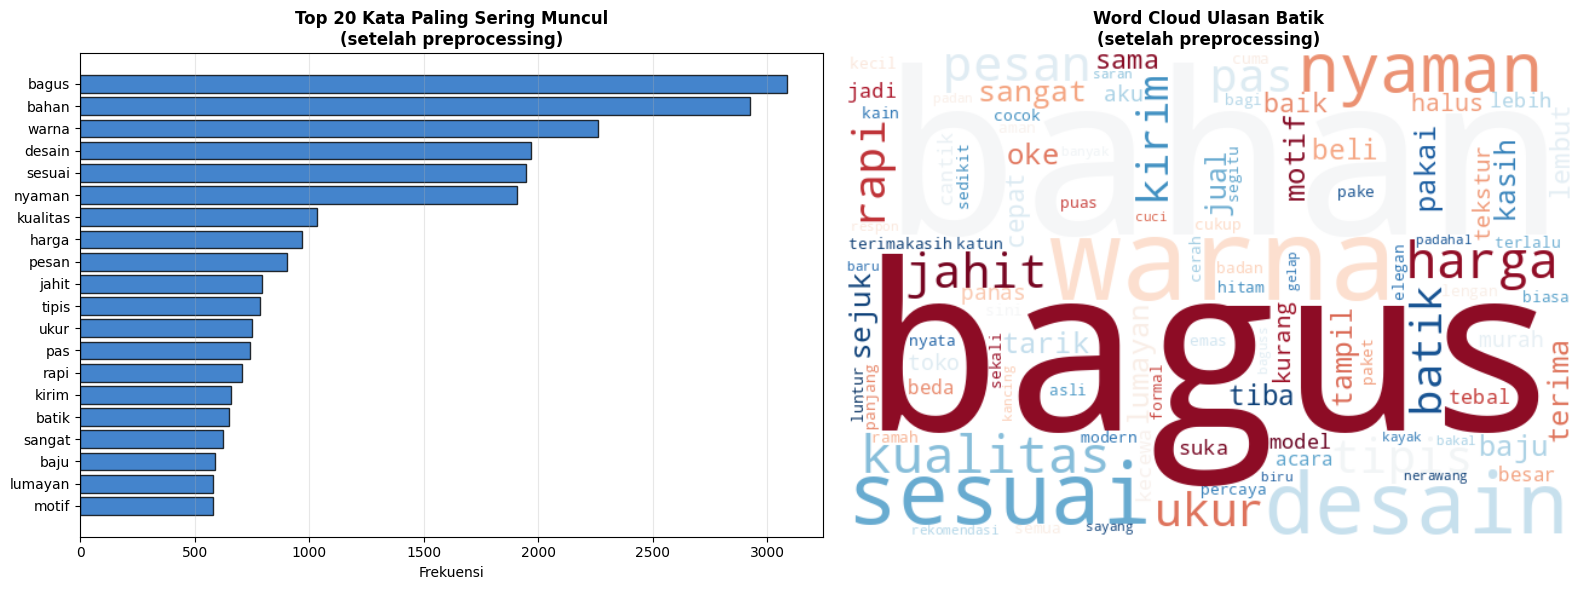

Top 30 kata:
    Kata  Frekuensi
   bagus       3088
   bahan       2924
   warna       2262
  desain       1970
  sesuai       1946
  nyaman       1908
kualitas       1035
   harga        967
   pesan        903
   jahit        796
   tipis        787
    ukur        751
     pas        744
    rapi        706
   kirim        661
   batik        649
  sangat        624
    baju        589
 lumayan        582
   motif        581
     oke        561
   sejuk        549
   pakai        539
   tarik        528
  terima        525
  tampil        491
    tiba        483
   kasih        470
    beli        458
    jual        455


In [24]:
from collections import Counter

# Semua token setelah preprocessing
all_tokens = [token for tokens in df_clean['tokens_stem'] for token in tokens]
word_freq = Counter(all_tokens)
top_words = pd.DataFrame(word_freq.most_common(30), columns=['Kata', 'Frekuensi'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart top 20
top20 = top_words.head(20)
axes[0].barh(top20['Kata'][::-1], top20['Frekuensi'][::-1], color='#1565c0', edgecolor='black', alpha=0.8)
axes[0].set_title('Top 20 Kata Paling Sering Muncul\n(setelah preprocessing)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Frekuensi')
axes[0].grid(axis='x', alpha=0.3)

# WordCloud
wc = WordCloud(width=600, height=400, background_color='white',
               colormap='RdBu', max_words=100, collocations=False)
wc.generate_from_frequencies(word_freq)
axes[1].imshow(wc, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud Ulasan Batik\n(setelah preprocessing)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('wordcloud_top_kata.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 30 kata:')
print(top_words.to_string(index=False))

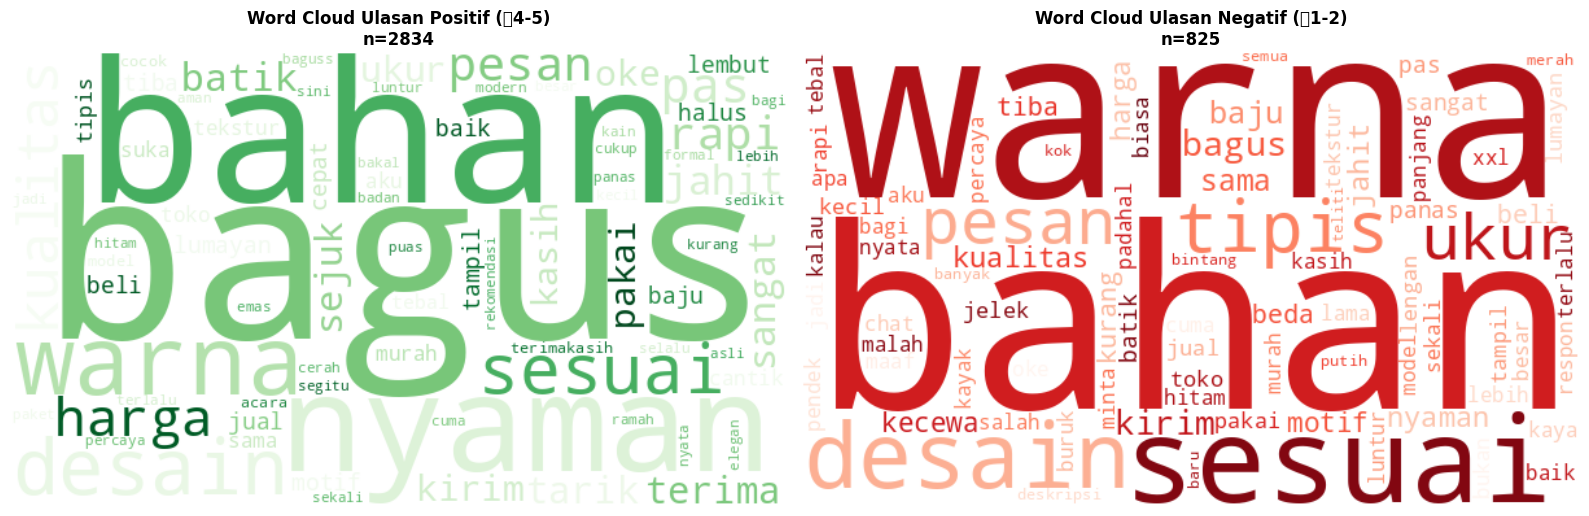

In [25]:
# WordCloud per sentiment (rating tinggi vs rendah)
df_positif = df_clean[df_clean['Rating'] >= 4]
df_negatif = df_clean[df_clean['Rating'] <= 2]

tokens_pos = [t for tokens in df_positif['tokens_stem'] for t in tokens]
tokens_neg = [t for tokens in df_negatif['tokens_stem'] for t in tokens]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

if tokens_pos:
    wc_pos = WordCloud(width=600, height=350, background_color='white',
                       colormap='Greens', max_words=80, collocations=False)
    wc_pos.generate_from_frequencies(Counter(tokens_pos))
    axes[0].imshow(wc_pos, interpolation='bilinear')
    axes[0].axis('off')
    axes[0].set_title(f'Word Cloud Ulasan Positif (⭐4-5)\nn={len(df_positif)}', fontsize=12, fontweight='bold')

if tokens_neg:
    wc_neg = WordCloud(width=600, height=350, background_color='white',
                       colormap='Reds', max_words=80, collocations=False)
    wc_neg.generate_from_frequencies(Counter(tokens_neg))
    axes[1].imshow(wc_neg, interpolation='bilinear')
    axes[1].axis('off')
    axes[1].set_title(f'Word Cloud Ulasan Negatif (⭐1-2)\nn={len(df_negatif)}', fontsize=12, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'Data ulasan negatif terlalu sedikit', ha='center', va='center')
    axes[1].axis('off')

plt.tight_layout()
plt.savefig('wordcloud_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()

# 4.6 Analisis Aspek (Kata Kunci Produk Batik)

=== Distribusi Aspek dalam Ulasan ===
     Aspek  Jumlah Ulasan  Persentase (%)
  Kualitas           3582            81.6
    Desain           2982            67.9
Kenyamanan           1739            39.6
    Ukuran           1192            27.2


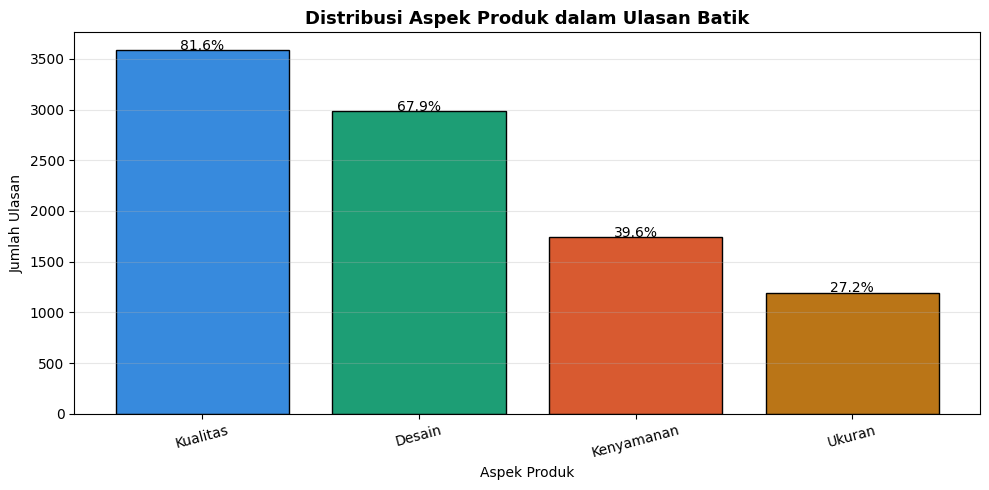

Distribusi Aspek Dominan per Ulasan (aspek_keyword)
aspek_keyword
Kualitas      2790
Desain        1278
Ukuran         182
Kenyamanan     140
Name: count, dtype: int64
  Desain      : 1278 ulasan (29.1%)
  Kualitas    : 2790 ulasan (63.6%)
  Kenyamanan  :  140 ulasan (3.2%)
  Ukuran      :  182 ulasan (4.1%)

✅ Kolom aspek_keyword berhasil ditambahkan ke df_clean!


In [26]:

aspek_batik = {
    'Desain'     : ['desain', 'motif', 'corak', 'warna', 'cantik', 'indah',
                    'menarik', 'elegan', 'modern', 'keren', 'gambar', 'pola',
                    'model', 'tampil', 'estetik', 'visual'],
    'Kualitas'   : ['bahan', 'kain', 'halus', 'lembut', 'tebal', 'tipis',
                    'katun', 'polyester', 'jahit', 'rapi', 'kualitas',
                    'furing', 'lapis', 'kancing', 'awet', 'bagus',
                    'tekstur', 'material', 'benang', 'kuat'],
    'Kenyamanan' : ['nyaman', 'kenyaman', 'comfort', 'enak', 'adem', 'sejuk',
                    'gerah', 'panas', 'dingin', 'segar', 'keringat',
                    'bernapas', 'ringan', 'berat'],
    'Ukuran'     : ['ukuran', 'size', 'pas', 'cocok', 'besar', 'kecil',
                    'panjang', 'pendek', 'slim', 'ramping', 'fitting',
                    'xl', 'xxl', 'longgar', 'sempit', 'fit'],
}

# ── Hitung frekuensi (jumlah ulasan yang menyebut tiap aspek) ──
aspek_counts = {}
for aspek, keywords in aspek_batik.items():
    count = sum(1 for tokens in df_clean['tokens_stem']
                if any(k in tokens for k in keywords))
    aspek_counts[aspek] = count

aspek_df = pd.DataFrame(list(aspek_counts.items()), columns=['Aspek', 'Jumlah Ulasan'])
aspek_df['Persentase (%)'] = (aspek_df['Jumlah Ulasan'] / len(df_clean) * 100).round(1)
aspek_df = aspek_df.sort_values('Jumlah Ulasan', ascending=False).reset_index(drop=True)

print('=== Distribusi Aspek dalam Ulasan ===')
print(aspek_df.to_string(index=False))

# ── Visualisasi ──
fig, ax = plt.subplots(figsize=(10, 5))
colors_aspek_eda = ['#378ADD', '#1D9E75', '#D85A30', '#BA7517']
bars = ax.bar(aspek_df['Aspek'], aspek_df['Jumlah Ulasan'],
              color=colors_aspek_eda[:len(aspek_df)], edgecolor='black')
ax.set_title('Distribusi Aspek Produk dalam Ulasan Batik', fontsize=13, fontweight='bold')
ax.set_xlabel('Aspek Produk')
ax.set_ylabel('Jumlah Ulasan')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)
for bar, pct in zip(bars, aspek_df['Persentase (%)']):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            f'{pct}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('distribusi_aspek.png', dpi=150, bbox_inches='tight')
plt.show()

# ── PENTING: Tugaskan aspek DOMINAN per ulasan ke df_clean ──
# Setiap ulasan mendapat 1 aspek berdasarkan keyword match terbanyak.
# Jika tidak ada keyword sama sekali, aspek diisi 'Kualitas' (fallback).
def assign_aspek_dominan(tokens):
    skor = {}
    for aspek, keywords in aspek_batik.items():
        skor[aspek] = sum(1 for t in tokens if t in keywords)
    best_aspek = max(skor, key=skor.get)
    return best_aspek if skor[best_aspek] > 0 else 'Kualitas'

df_clean['aspek_keyword'] = df_clean['tokens_stem'].apply(assign_aspek_dominan)

print("Distribusi Aspek Dominan per Ulasan (aspek_keyword)")
dist_kw = df_clean['aspek_keyword'].value_counts()
print(dist_kw)
pct_kw = (dist_kw / len(df_clean) * 100).round(1)
for aspek in ['Desain', 'Kualitas', 'Kenyamanan', 'Ukuran']:
    n   = dist_kw.get(aspek, 0)
    pct = pct_kw.get(aspek, 0.0)
    print(f'  {aspek:<12}: {n:>4} ulasan ({pct}%)')
print('\n✅ Kolom aspek_keyword berhasil ditambahkan ke df_clean!')


# 4.7 Simpan Dataset Hasil Preprocessing

In [27]:
# Simpan dataset yang sudah dipreproses (termasuk kolom aspek_keyword)
kolom_simpan = ['User Id', 'User Name', 'Comment', 'text_preprocessed',
                'Rating', 'Detail Rating', 'Product Id', 'Product Name', 'Shop Id',
                'aspek_keyword']
kolom_ada = [c for c in kolom_simpan if c in df_clean.columns]
df_final = df_clean[kolom_ada].copy()
df_final.columns = [c if c != 'text_preprocessed' else 'Text_Preprocessed' for c in df_final.columns]

# Simpan ke CSV
df_final.to_csv('batik_preprocessed.csv', index=False, encoding='utf-8')
print(f'✅ Dataset tersimpan: batik_preprocessed.csv ({len(df_final)} baris)')
print(f'Kolom: {list(df_final.columns)}')
df_final.head()


✅ Dataset tersimpan: batik_preprocessed.csv (4390 baris)
Kolom: ['User Id', 'User Name', 'Comment', 'Text_Preprocessed', 'Rating', 'Detail Rating', 'Product Id', 'Product Name', 'Shop Id', 'aspek_keyword']


,User Id,User Name,Comment,Text_Preprocessed,Rating,Detail Rating,Product Id,Product Name,Shop Id,aspek_keyword
0,239772482,l*****e,Desain:bagus\nBahan:cukup berkualitas\nKenyama...,desain bagus bahan cukup kualitas nyaman furin...,4,product_quality: 4\nseller_service: 5\ndeliver...,28751481863,Batik Indonesia Motif ABIMATA Kemeja Batik Sli...,1088913202,Kualitas
1,818084703,m*****5,Desain:keren dan moderen\nBahan:bagus\nTekstur...,desain bagus moderen bahan bagus tekstur lembu...,4,product_quality: 4\nseller_service: 4\ndeliver...,28751481863,Batik Indonesia Motif ABIMATA Kemeja Batik Sli...,1088913202,Kualitas
2,227253735,ari.irawan,Desain:batik dg desain yg bagus\nBahan:halus d...,desain batik desain bagus bahan halus nyaman t...,4,product_quality: 4,28751481863,Batik Indonesia Motif ABIMATA Kemeja Batik Sli...,1088913202,Kualitas
3,1316081004,garasibarbersop,Desain:bagus\nBahan:lmbut\nKenyamanan:passs di...,desain bagus bahan lmbut nyaman passs dipkainy...,4,product_quality: 4,28751481863,Batik Indonesia Motif ABIMATA Kemeja Batik Sli...,1088913202,Kualitas
4,311327546,b*****1,Desain:motif mewah dan hidup\nBahan:kualitas s...,desain motif mewah hidup bahan kualitas sesuai...,4,product_quality: 4\nseller_service: 5\ndeliver...,28751481863,Batik Indonesia Motif ABIMATA Kemeja Batik Sli...,1088913202,Kualitas


In [28]:
# Download file
from google.colab import files
files.download('batik_preprocessed.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 4.8 Ringkasan Hasil EDA dan Preprocessing

In [29]:
print('='*60)
print('RINGKASAN EDA DAN PREPROCESSING')
print('='*60)
print(f'\n📊 DATASET:')
print(f'  - Data awal              : {len(df):,} baris')
print(f'  - Data setelah cleaning  : {len(df_clean):,} baris')
print(f'  - Jumlah produk unik     : {df["Product Name"].nunique():,}')
print(f'  - Jumlah user unik       : {df["User Id"].nunique():,}')

print(f'\n⭐ DISTRIBUSI RATING:')
for r, c in df['Rating'].value_counts().sort_index().items():
    print(f'  - Rating {r}: {c:,} ({c/len(df)*100:.1f}%)')

print(f'\n🔤 PREPROCESSING:')
print(f'  - Tahapan: Case Folding → Noise Removal → Normalisasi → Tokenization → Stopword Removal → Stemming')
print(f'  - Kamus normalisasi      : {len(kamus_normalisasi)} kata')
print(f'  - Jumlah stopword        : {len(all_stopwords)}')
print(f'  - Rata-rata token awal   : {df_clean["jml_token_awal"].mean():.1f}')
print(f'  - Rata-rata token akhir  : {df_clean["jml_token_akhir"].mean():.1f}')
print(f'  - Reduksi rata-rata      : {df_clean["reduksi_pct"].mean():.1f}%')

print(f'\n🏷️  ASPEK DOMINAN:')
for _, row in aspek_df.head(3).iterrows():
    print(f'  - {row["Aspek"]}: {row["Jumlah Ulasan"]:,} ulasan ({row["Persentase (%)"]:.1f}%)')

print('\n✅ Preprocessing selesai. Data siap untuk pemodelan BERTopic → EFM')
print('='*60)

RINGKASAN EDA DAN PREPROCESSING

📊 DATASET:
  - Data awal              : 5,407 baris
  - Data setelah cleaning  : 4,390 baris
  - Jumlah produk unik     : 115
  - Jumlah user unik       : 5,105

⭐ DISTRIBUSI RATING:
  - Rating 1: 591 (10.9%)
  - Rating 2: 615 (11.4%)
  - Rating 3: 936 (17.3%)
  - Rating 4: 1,192 (22.0%)
  - Rating 5: 2,073 (38.3%)

🔤 PREPROCESSING:
  - Tahapan: Case Folding → Noise Removal → Normalisasi → Tokenization → Stopword Removal → Stemming
  - Kamus normalisasi      : 113 kata
  - Jumlah stopword        : 177
  - Rata-rata token awal   : 17.9
  - Rata-rata token akhir  : 14.2
  - Reduksi rata-rata      : 11.2%

🏷️  ASPEK DOMINAN:
  - Kualitas: 3,582 ulasan (81.6%)
  - Desain: 2,982 ulasan (67.9%)
  - Kenyamanan: 1,739 ulasan (39.6%)

✅ Preprocessing selesai. Data siap untuk pemodelan BERTopic → EFM


# 4.9 Pemodelan Topik Menggunakan BERTopic

Sesuai metodologi BAB III Skripsi:
- Model Embedding : paraphrase-multilingual-MiniLM-L12-v2
- Reduksi Dimensi : UMAP
- Clustering      : HDBSCAN
- Representasi    : class-based TF-IDF (c-TF-IDF)
- Aspek Final     : Desain, Kualitas, Ukuran, Harga (K=4)

## 4.9.1 Instalasi Library BERTopic


In [30]:
!pip install bertopic sentence-transformers umap-learn hdbscan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 2.8 MB/s eta 0:00:00


## 4.9.2 Import Library BERTopic

In [31]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

print("✅ Semua library BERTopic berhasil di-import!")

✅ Semua library BERTopic berhasil di-import!


## 4.9.3 Persiapan Data untuk BERTopic

In [32]:
# Pastikan df_clean sudah tersedia dari tahap preprocessing
assert 'df_clean' in dir(), "❌ df_clean belum ada. Jalankan sel preprocessing terlebih dahulu!"
assert 'text_preprocessed' in df_clean.columns, "❌ Kolom text_preprocessed belum ada!"

# Gunakan teks yang sudah dipreproses
docs = df_clean['text_preprocessed'].tolist()

# Filter dokumen yang terlalu pendek (< 3 kata)
df_clean['token_count'] = df_clean['text_preprocessed'].str.split().str.len()
mask_valid = df_clean['token_count'] >= 3
docs_valid = df_clean.loc[mask_valid, 'text_preprocessed'].tolist()
idx_valid  = df_clean.loc[mask_valid].index.tolist()

print(f"Total dokumen           : {len(docs)}")
print(f"Dokumen valid (≥3 kata) : {len(docs_valid)}")
print(f"Dokumen dibuang         : {len(docs) - len(docs_valid)}")
print(f"\nContoh dokumen:\n  [{docs_valid[0]}]\n  [{docs_valid[1]}]")

Total dokumen           : 4390
Dokumen valid (≥3 kata) : 4165
Dokumen dibuang         : 225

Contoh dokumen:
  [desain bagus bahan cukup kualitas nyaman furing tinggi pas]
  [desain bagus moderen bahan bagus tekstur lembut halus kirim cepat peking rapi]


## 4.9.4 Inisialisasi Sentence Transformer (Embedding)

In [33]:
# Mendukung Bahasa Indonesia + multilingual
# Cocok untuk teks pendek (ulasan e-commerce)

print("⏳ Memuat model embedding...")
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

print("⏳ Membuat embedding dokumen (proses ini memerlukan waktu)...")
embeddings = embedding_model.encode(docs_valid, show_progress_bar=True, batch_size=64)
print(f"✅ Embedding selesai! Shape: {embeddings.shape}")

⏳ Memuat model embedding...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

⏳ Membuat embedding dokumen (proses ini memerlukan waktu)...


Batches:   0%|          | 0/66 [00:00<?, ?it/s]

✅ Embedding selesai! Shape: (4165, 384)


## 4.9.5 Konfigurasi Komponen BERTopic

In [34]:
# --- UMAP: Reduksi Dimensi ---
umap_model = UMAP(
    n_neighbors=15,        # jumlah tetangga lokal
    n_components=3,        # dimensi target
    min_dist=0.0,          # jarak minimum antar titik (0 = klaster lebih padat)
    metric='cosine',       # metrik jarak untuk embedding teks
    random_state=42        # reproducibility
)

# --- HDBSCAN: Clustering ---
hdbscan_model = HDBSCAN(
    min_cluster_size=5,   # minimum dokumen per klaster (aspek)
    min_samples=5,         # kontrol noise sensitivity
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True   # diperlukan untuk transform data baru
)
# --- CountVectorizer: Representasi Topik ---
# Stopword + min_df untuk membatasi kata noise
vectorizer_model = CountVectorizer(
    min_df=2,              # kata harus muncul minimal di 2 dokumen
    ngram_range=(1, 2),    # unigram + bigram
    max_features=5000
)

print("✅ Konfigurasi komponen BERTopic selesai!")
print(f"   UMAP      : n_neighbors=15, n_components=5, metric=cosine")
print(f"   HDBSCAN   : min_cluster_size=10, min_samples=5")
print(f"   Vectorizer: ngram_range=(1,2), min_df=2")


✅ Konfigurasi komponen BERTopic selesai!
   UMAP      : n_neighbors=15, n_components=5, metric=cosine
   HDBSCAN   : min_cluster_size=10, min_samples=5
   Vectorizer: ngram_range=(1,2), min_df=2


## 4.9.6 Training BERTopic

In [35]:
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    nr_topics=4,      # biarkan BERTopic menentukan jumlah topik otomatis
    top_n_words=10,        # kata kunci per topik
    calculate_probabilities=True,
    verbose=True
)

print("⏳ Training BERTopic... (proses ini memerlukan beberapa menit)")
topics, probs = topic_model.fit_transform(docs_valid, embeddings=embeddings)
print("✅ BERTopic selesai dilatih!")

2026-07-07 04:37:41,796 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


⏳ Training BERTopic... (proses ini memerlukan beberapa menit)


2026-07-07 04:38:19,422 - BERTopic - Dimensionality - Completed ✓
2026-07-07 04:38:19,424 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-07 04:38:25,003 - BERTopic - Cluster - Completed ✓
2026-07-07 04:38:25,004 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-07-07 04:38:25,284 - BERTopic - Representation - Completed ✓
2026-07-07 04:38:25,285 - BERTopic - Topic reduction - Reducing number of topics
2026-07-07 04:38:25,317 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-07 04:38:25,532 - BERTopic - Representation - Completed ✓
2026-07-07 04:38:25,535 - BERTopic - Topic reduction - Reduced number of topics from 137 to 4


✅ BERTopic selesai dilatih!


## 4.9.7 Eksplorasi Hasil Topik

In [36]:
topic_info = topic_model.get_topic_info()
n_topics = len(topic_info[topic_info['Topic'] != -1])
n_outlier = (np.array(topics) == -1).sum()

print("=" * 60)
print(f"HASIL PEMODELAN BERTOPIC")
print("=" * 60)
print(f"Jumlah topik ditemukan : {n_topics}")
print(f"Dokumen outlier (-1)   : {n_outlier} ({n_outlier/len(docs_valid)*100:.1f}%)")
print(f"Dokumen ter-assign     : {len(docs_valid) - n_outlier}")
print()
print("=== Daftar Topik ===")
print(topic_info[topic_info['Topic'] != -1][['Topic', 'Count', 'Name']].to_string(index=False))

HASIL PEMODELAN BERTOPIC
Jumlah topik ditemukan : 3
Dokumen outlier (-1)   : 1375 (33.0%)
Dokumen ter-assign     : 2790

=== Daftar Topik ===
 Topic  Count                             Name
     0   2637       0_bagus_bahan_warna_desain
     1    145        1_pesan_terima_ukur_kirim
     2      8 2_lambat_respon_slow respon_slow


## 4.9.8 Detail Kata Kunci per Topik

In [37]:
print("\n=== Kata Kunci per Topik ===")
for topic_id in sorted(topic_info[topic_info['Topic'] != -1]['Topic'].tolist()):
    words_scores = topic_model.get_topic(topic_id)
    words = [w for w, s in words_scores[:8]]
    print(f"  Topik {topic_id:2d} : {', '.join(words)}")



=== Kata Kunci per Topik ===
  Topik  0 : bagus, bahan, warna, desain, sesuai, nyaman, batik, kualitas
  Topik  1 : pesan, terima, ukur, kirim, sesuai, kasih, bagus, tiba
  Topik  2 : lambat, respon, slow respon, slow, cepat, pesan, kirim, respon jual


## 4.9.9 Mapping Topik → Aspek Produk Batik

In [38]:

aspek_keywords = {
    'Desain'     : ['desain', 'motif', 'corak', 'warna', 'cantik', 'indah',
                    'menarik', 'elegan', 'model', 'gambar', 'pola', 'keren'],
    'Kenyamanan' : ['nyaman', 'kenyaman', 'comfort', 'enak', 'adem', 'sejuk',
                    'gerah', 'panas', 'dingin', 'segar'],
    'Kualitas'   : ['bahan', 'kain', 'halus', 'lembut', 'tebal', 'tipis',
                    'jahit', 'rapi', 'kualitas', 'awet', 'furing', 'katun'],
    'Ukuran'     : ['ukuran', 'size', 'pas', 'cocok', 'besar', 'kecil',
                    'panjang', 'pendek', 'slim', 'fitting', 'xl', 'xxl'],
}

def auto_map_topic_to_aspek(topic_id, top_n=10):

    words_scores = topic_model.get_topic(topic_id)
    topic_words = set([w.lower() for w, s in words_scores[:top_n]])

    best_aspek = 'Kualitas'
    best_score = 0
    for aspek, keywords in aspek_keywords.items():
        score = len(topic_words & set(keywords))
        if score > best_score:
            best_score = score
            best_aspek = aspek

    return best_aspek, best_score

# Auto-mapping
print("\n=== Auto-Mapping Topik → Aspek ===")
topic_aspek_map = {}
for topic_id in sorted(topic_info[topic_info['Topic'] != -1]['Topic'].tolist()):
    aspek, score = auto_map_topic_to_aspek(topic_id)
    topic_aspek_map[topic_id] = aspek
    words = [w for w, s in topic_model.get_topic(topic_id)[:6]]
    print(f"  Topik {topic_id:2d} → {aspek:12s} (skor={score}) | kata: {words}")


print("Contoh override manual:")
print("   topic_aspek_map[2] = 'Kenyamanan'  ")
print("   topic_aspek_map[3] = 'Ukuran'      ")



=== Auto-Mapping Topik → Aspek ===
  Topik  0 → Kualitas     (skor=3) | kata: ['bagus', 'bahan', 'warna', 'desain', 'sesuai', 'nyaman']
  Topik  1 → Kualitas     (skor=0) | kata: ['pesan', 'terima', 'ukur', 'kirim', 'sesuai', 'kasih']
  Topik  2 → Kualitas     (skor=0) | kata: ['lambat', 'respon', 'slow respon', 'slow', 'cepat', 'pesan']
Contoh override manual:
   topic_aspek_map[2] = 'Kenyamanan'  
   topic_aspek_map[3] = 'Ukuran'      


## 4.9.10 Assign Aspek ke Setiap Dokumen

In [39]:
# Tambahkan kolom topic dan aspek ke df_clean
df_clean['topic_bertopic'] = -1
df_clean['aspek_bertopic'] = 'Outlier'
df_clean['topic_prob']     = 0.0

df_clean.loc[idx_valid, 'topic_bertopic'] = topics

# Map topic → aspek
df_clean['aspek_bertopic'] = df_clean['topic_bertopic'].map(
    lambda t: topic_aspek_map.get(t, 'Outlier') if t != -1 else 'Outlier'
)

# Simpan probabilitas tertinggi (jika tersedia)
if probs is not None and len(probs) > 0:
    try:
        max_probs = probs.max(axis=1) if probs.ndim > 1 else probs
        df_clean.loc[idx_valid, 'topic_prob'] = max_probs
    except Exception:
        pass
# Rekap distribusi aspek
aspek_dist = df_clean[df_clean['aspek_bertopic'] != 'Outlier']['aspek_bertopic'].value_counts()
print("=== Distribusi Aspek (BERTopic) ===")
print(aspek_dist)
total_valid = (df_clean['aspek_bertopic'] != 'Outlier').sum()
print(f"\nTotal dokumen ter-assign ke aspek : {total_valid}")
print(f"Total dokumen outlier             : {(df_clean['aspek_bertopic'] == 'Outlier').sum()}")

=== Distribusi Aspek (BERTopic) ===
aspek_bertopic
Kualitas    2790
Name: count, dtype: int64

Total dokumen ter-assign ke aspek : 2790
Total dokumen outlier             : 1600


## 4.9.11 Visualisasi Distribusi Aspek BERTopic

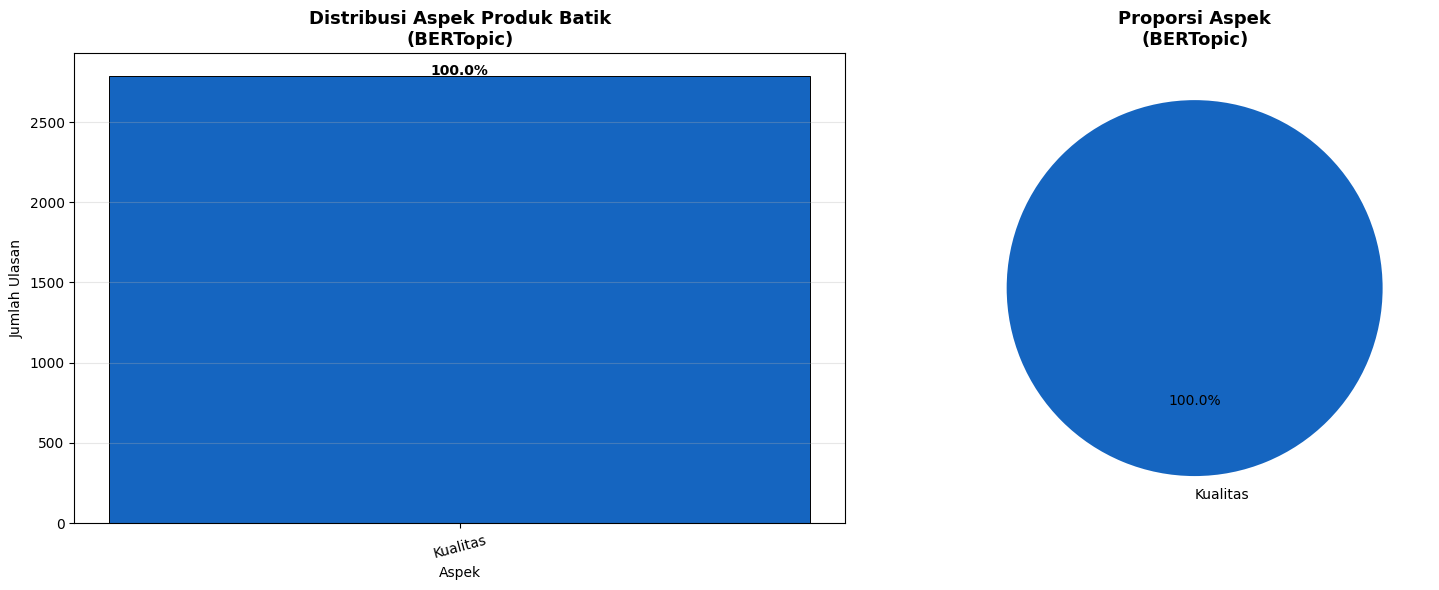

✅ Visualisasi distribusi aspek tersimpan: distribusi_aspek_bertopic.png


In [40]:
df_viz = df_clean[df_clean['aspek_bertopic'] != 'Outlier'].copy()
aspek_counts = df_viz['aspek_bertopic'].value_counts()
aspek_pct    = (aspek_counts / aspek_counts.sum() * 100).round(1)

colors_aspek = ['#1565c0', '#2e7d32', '#e65100', '#6a1b9a', '#c62828', '#00838f']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Bar chart ---
bars = axes[0].bar(aspek_counts.index, aspek_counts.values,
                   color=colors_aspek[:len(aspek_counts)], edgecolor='black', linewidth=0.7)
axes[0].set_title('Distribusi Aspek Produk Batik\n(BERTopic)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Aspek')
axes[0].set_ylabel('Jumlah Ulasan')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)
for bar, pct in zip(bars, aspek_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 3,
                 f'{pct}%', ha='center', fontsize=10, fontweight='bold')
    # --- Pie chart ---
axes[1].pie(aspek_counts.values,
            labels=aspek_counts.index,
            autopct='%1.1f%%',
            colors=colors_aspek[:len(aspek_counts)],
            startangle=90,
            textprops={'fontsize': 10})
axes[1].set_title('Proporsi Aspek\n(BERTopic)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('distribusi_aspek_bertopic.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisasi distribusi aspek tersimpan: distribusi_aspek_bertopic.png")

## 4.9.12 Visualisasi Kata Kunci per Aspek (Bar Chart)

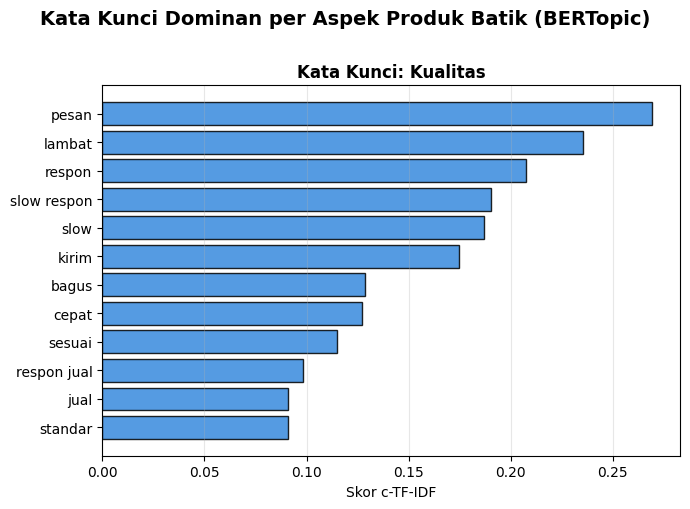

✅ Visualisasi kata kunci tersimpan: kata_kunci_aspek_bertopic.png


In [41]:
# Kumpulkan topik per aspek dan gabungkan kata kunci
ASPEK_URUT = ['Desain', 'Kualitas', 'Kenyamanan', 'Ukuran']
aspek_unik = [a for a in ASPEK_URUT if a in aspek_counts.index]
n_aspek = len(aspek_unik)
cols = min(2, n_aspek)
rows_plot = (n_aspek + cols - 1) // cols

fig, axes = plt.subplots(rows_plot, cols, figsize=(7 * cols, 5 * rows_plot))
if n_aspek == 1:
    axes = [axes]
else:
    axes = axes.flatten()

colors_aspek = ['#378ADD', '#1D9E75', '#D85A30', '#BA7517']

for i, aspek in enumerate(aspek_unik):
    # Topik yang termasuk aspek ini
    topik_ids = [t for t, a in topic_aspek_map.items() if a == aspek]
    if not topik_ids:
        axes[i].text(0.5, 0.5, 'Tidak ada topik', ha='center', va='center')
        axes[i].axis('off')
        continue
    # Gabungkan kata kunci dari semua topik aspek ini
    word_scores = {}
    for tid in topik_ids:
        for word, score in topic_model.get_topic(tid)[:15]:
            word_scores[word] = word_scores.get(word, 0) + score

    top_words = sorted(word_scores.items(), key=lambda x: x[1], reverse=True)[:12]
    words  = [w for w, s in top_words][::-1]
    scores = [s for w, s in top_words][::-1]

    axes[i].barh(words, scores, color=colors_aspek[i], edgecolor='black', alpha=0.85)
    axes[i].set_title(f'Kata Kunci: {aspek}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Skor c-TF-IDF')
    axes[i].grid(axis='x', alpha=0.3)

# Sembunyikan axes kosong
for j in range(len(aspek_unik), len(axes)):
    axes[j].axis('off')

plt.suptitle('Kata Kunci Dominan per Aspek Produk Batik (BERTopic)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('kata_kunci_aspek_bertopic.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisasi kata kunci tersimpan: kata_kunci_aspek_bertopic.png")


## 4.9.13 Tabel Sampel Hasil Aspek

In [42]:
print("\n=== Sampel Hasil Penugasan Aspek BERTopic ===")
sample_cols = ['Comment', 'text_preprocessed', 'aspek_bertopic', 'Rating']
sample_cols_ada = [c for c in sample_cols if c in df_clean.columns]
tabel_sampel = df_clean[df_clean['aspek_bertopic'] != 'Outlier'][sample_cols_ada].head(12)
tabel_sampel.columns = ['Ulasan Asli', 'Teks Preprocessed', 'Aspek', 'Rating'][:len(sample_cols_ada)]
print(tabel_sampel.to_string(index=False))


=== Sampel Hasil Penugasan Aspek BERTopic ===
                                                                                                                                                                                                                        Ulasan Asli                                                                                                                                                  Teks Preprocessed    Aspek  Rating
                                                                                                                                Desain:bagus\nBahan:cukup berkualitas\nKenyamanan:ada furing nya\n\nBuat BB 82 dan tinggi 168.. Pas                                                                                                         desain bagus bahan cukup kualitas nyaman furing tinggi pas Kualitas       4
Desain:batik dg desain yg bagus\nBahan:halus dan nyaman\nTekstur:sangat lembut dan halus\n\nJos bahanya.... Ukuran M pas TPI perut buncit

## 4.9.14 Evaluasi Koherensi Topik

In [43]:
print("\n=== Evaluasi Koherensi Topik ===")
topic_coherence = {}
for topic_id in sorted(topic_info[topic_info['Topic'] != -1]['Topic'].tolist()):
    words_scores = topic_model.get_topic(topic_id)
    scores = [s for w, s in words_scores[:10]]
    mean_score = np.mean(scores) if scores else 0
    topic_coherence[topic_id] = mean_score

coh_df = pd.DataFrame([
    {'Topik': tid, 'Aspek': topic_aspek_map.get(tid, '-'), 'Skor c-TF-IDF (mean top-10)': score}
    for tid, score in topic_coherence.items()
])
print(coh_df.to_string(index=False))
print(f"\nRata-rata skor koherensi keseluruhan: {np.mean(list(topic_coherence.values())):.4f}")


=== Evaluasi Koherensi Topik ===
 Topik    Aspek  Skor c-TF-IDF (mean top-10)
     0 Kualitas                     0.051087
     1 Kualitas                     0.067905
     2 Kualitas                     0.146450

Rata-rata skor koherensi keseluruhan: 0.0885


## 4.9.15 Simpan Hasil BERTopic

In [44]:
# Simpan dataset dengan kolom aspek
kolom_simpan = ['User Id', 'User Name', 'Comment', 'text_preprocessed',
                'Rating', 'Product Id', 'Product Name', 'Shop Id',
                'aspek_bertopic', 'topic_bertopic']
kolom_ada = [c for c in kolom_simpan if c in df_clean.columns]
df_bertopic = df_clean[kolom_ada].copy()

df_bertopic.to_csv('batik_bertopic.csv', index=False, encoding='utf-8')
print(f"\n✅ Dataset tersimpan: batik_bertopic.csv ({len(df_bertopic)} baris)")
print(f"   Kolom: {list(df_bertopic.columns)}")


✅ Dataset tersimpan: batik_bertopic.csv (4390 baris)
   Kolom: ['User Id', 'User Name', 'Comment', 'text_preprocessed', 'Rating', 'Product Id', 'Product Name', 'Shop Id', 'aspek_bertopic', 'topic_bertopic']


## 4.9.16 Ringkasan Hasil BERTopic

In [45]:
print("=" * 60)
print("RINGKASAN HASIL PEMODELAN BERTOPIC")
print("=" * 60)
print(f"  Model Embedding  : paraphrase-multilingual-MiniLM-L12-v2")
print(f"  Reduksi Dimensi  : UMAP (n_neighbors=15, n_components=5)")
print(f"  Clustering       : HDBSCAN (min_cluster_size=10)")
print(f"  Representasi     : c-TF-IDF (CountVectorizer ngram 1-2)")
print(f"\n  Jumlah topik ditemukan : {n_topics}")
print(f"  Dokumen valid    : {len(docs_valid)}")
print(f"  Dokumen outlier  : {n_outlier} ({n_outlier/len(docs_valid)*100:.1f}%)")
print(f"\n  Distribusi Aspek Final (K=4):")
for aspek in ['Desain', 'Kualitas', 'Kenyamanan', 'Ukuran']:
    count = (df_clean['aspek_bertopic'] == aspek).sum()
    pct   = count / len(df_clean) * 100
    print(f"    {aspek:12s}: {count:4d} ulasan ({pct:.1f}%)")
print(f"\n✅ BERTopic selesai. Lanjut ke tahap EFM (Section 4.10)")
print("=" * 60)


RINGKASAN HASIL PEMODELAN BERTOPIC
  Model Embedding  : paraphrase-multilingual-MiniLM-L12-v2
  Reduksi Dimensi  : UMAP (n_neighbors=15, n_components=5)
  Clustering       : HDBSCAN (min_cluster_size=10)
  Representasi     : c-TF-IDF (CountVectorizer ngram 1-2)

  Jumlah topik ditemukan : 3
  Dokumen valid    : 4165
  Dokumen outlier  : 1375 (33.0%)

  Distribusi Aspek Final (K=4):
    Desain      :    0 ulasan (0.0%)
    Kualitas    : 2790 ulasan (63.6%)
    Kenyamanan  :    0 ulasan (0.0%)
    Ukuran      :    0 ulasan (0.0%)

✅ BERTopic selesai. Lanjut ke tahap EFM (Section 4.10)


## 4.9.17 Download file (Google Colab)

In [46]:
from google.colab import files
files.download('batik_bertopic.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 4.10 Explicit Factor Model (EFM)

Sesuai metodologi skripsi BAB III (Sections 3.7–3.11), tahap ini mencakup:
- **3.7** Splitting Data (80:20)
- **3.8** Pembobotan Aspek Pengguna (w_au)
- **3.9** Kualitas Produk per Aspek (q_pa)
- **3.10** Prediksi Rating EFM
- **3.11** Evaluasi RMSE, Precision-K, dan Explainability

## 4.10.1 Load Dataset Hasil BERTopic

In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Load hasil BERTopic
df_bert = pd.read_csv('batik_bertopic.csv')

KOLOM_WAJIB = ['User Id', 'Product Id', 'Rating', 'aspek_bertopic']
for k in KOLOM_WAJIB:
    assert k in df_bert.columns, f"❌ Kolom '{k}' tidak ditemukan. Jalankan Section 4.9 terlebih dahulu!"

print("✅ Dataset berhasil dimuat!")
print(f"   Total baris        : {len(df_bert):,}")
print(f"   Pengguna unik      : {df_bert['User Id'].nunique():,}")
print(f"   Produk unik        : {df_bert['Product Id'].nunique():,}")
print(f"   Aspek unik         : {df_bert['aspek_bertopic'].nunique():,}")
print(f"   Aspek tersedia     : {sorted(df_bert['aspek_bertopic'].dropna().unique())}")
df_bert.head()

# ── Gabungkan aspek_keyword dari df_clean jika tersedia ──
# (aspek_keyword dihasilkan Section 4.6 berdasarkan keyword matching)
if 'df_clean' in dir() and 'aspek_keyword' in df_clean.columns:
    aspek_kw_map = df_clean.set_index(
        df_clean.index if 'User Id' not in df_clean.columns
        else ['User Id', 'Product Id'] if 'Product Id' in df_clean.columns
        else df_clean.index
    )
    # merge berdasarkan Comment agar tidak salah join
    kw_series = df_clean[['Comment', 'aspek_keyword']].drop_duplicates('Comment')
    df_bert = df_bert.merge(kw_series, on='Comment', how='left')
    print(f"✅ Kolom aspek_keyword berhasil digabungkan dari df_clean")
elif 'aspek_keyword' in df_bert.columns:
    print("✅ Kolom aspek_keyword sudah ada di dataset")
else:
    print("⚠️  aspek_keyword tidak tersedia. Jalankan Section 4.6 sebelum memuat ulang notebook.")


✅ Dataset berhasil dimuat!
   Total baris        : 4,390
   Pengguna unik      : 4,301
   Produk unik        : 113
   Aspek unik         : 2
   Aspek tersedia     : ['Kualitas', 'Outlier']
✅ Kolom aspek_keyword berhasil digabungkan dari df_clean


## 4.10.2 Definisi Aspek Final

Sesuai skripsi BAB III.3.3.3: **4 aspek final** — Desain, Kualitas, Ukuran, Harga.

> **Catatan:** Ubah  di bawah jika nama aspek hasil BERTopic-mu berbeda.

In [48]:
# Sesuai skripsi BAB III.3.3.3: 4 aspek final
ASPEK_FINAL = ['Desain', 'Kualitas', 'Kenyamanan', 'Ukuran']

# ── Normalisasi aspek dari hasil BERTopic ──
aspek_map = {}
for a in df_bert['aspek_bertopic'].dropna().unique():
    a_lower = a.lower()
    if any(x in a_lower for x in ['desain', 'motif', 'warna', 'corak']):
        aspek_map[a] = 'Desain'
    elif any(x in a_lower for x in ['nyaman', 'kenyaman', 'comfort', 'adem', 'sejuk']):
        aspek_map[a] = 'Kenyamanan'
    elif any(x in a_lower for x in ['kual', 'bahan', 'jahit', 'kain', 'katun', 'furing']):
        aspek_map[a] = 'Kualitas'
    elif any(x in a_lower for x in ['ukuran', 'size', 'fit', 'pas']):
        aspek_map[a] = 'Ukuran'
    else:
        aspek_map[a] = 'Kualitas'

df_bert['aspek_norm'] = df_bert['aspek_bertopic'].map(aspek_map)

print("✅ Mapping aspek BERTopic:")
for orig, norm in aspek_map.items():
    print(f"   '{orig}' → '{norm}'")

# ── Cek aspek mana yang tercakup BERTopic ──
aspek_tercakup = set(df_bert['aspek_norm'].dropna().unique())
aspek_hilang   = set(ASPEK_FINAL) - aspek_tercakup
print(f"\nAspek tercakup BERTopic  : {sorted(aspek_tercakup)}")
print(f"Aspek tidak tercakup     : {sorted(aspek_hilang) if aspek_hilang else 'Tidak ada — semua aspek tercakup ✅'}")

# ── FALLBACK: jika ada aspek yang tidak tercakup BERTopic,
#    gunakan kolom aspek_keyword (dari keyword matching Section 4.6) ──
if aspek_hilang and 'aspek_keyword' in df_bert.columns:
    print(f"\n⚠️  Menggunakan aspek_keyword sebagai fallback untuk: {sorted(aspek_hilang)}")
    mask_outlier = df_bert['aspek_norm'].isna() | (df_bert['aspek_bertopic'] == 'Outlier')
    for aspek in aspek_hilang:
        mask_aspek = mask_outlier & (df_bert['aspek_keyword'] == aspek)
        df_bert.loc[mask_aspek, 'aspek_norm'] = aspek
        n_filled = mask_aspek.sum()
        print(f"   {aspek}: {n_filled} ulasan diisi dari aspek_keyword")
elif aspek_hilang:
    print(f"\n⚠️  Kolom aspek_keyword tidak tersedia. Pastikan menjalankan Section 4.6 terlebih dahulu.")

print(f"\nDistribusi aspek (setelah normalisasi + fallback):")
print(df_bert['aspek_norm'].value_counts())

# ── Pastikan SEMUA 4 aspek muncul (agar q_pa bisa dihitung) ──
for a in ASPEK_FINAL:
    n = (df_bert['aspek_norm'] == a).sum()
    status = "✅" if n > 0 else "❌ TIDAK ADA DATA — cek keyword aspek_batik di Section 4.6"
    print(f"  {a:<12}: {n:>4} ulasan {status}")


✅ Mapping aspek BERTopic:
   'Kualitas' → 'Kualitas'
   'Outlier' → 'Kualitas'

Aspek tercakup BERTopic  : ['Kualitas']
Aspek tidak tercakup     : ['Desain', 'Kenyamanan', 'Ukuran']

⚠️  Menggunakan aspek_keyword sebagai fallback untuk: ['Desain', 'Kenyamanan', 'Ukuran']
   Ukuran: 82 ulasan diisi dari aspek_keyword
   Kenyamanan: 54 ulasan diisi dari aspek_keyword
   Desain: 392 ulasan diisi dari aspek_keyword

Distribusi aspek (setelah normalisasi + fallback):
aspek_norm
Kualitas      3862
Desain         392
Ukuran          82
Kenyamanan      54
Name: count, dtype: int64
  Desain      :  392 ulasan ✅
  Kualitas    : 3862 ulasan ✅
  Kenyamanan  :   54 ulasan ✅
  Ukuran      :   82 ulasan ✅


## 4.10.3 Splitting Data (80:20)

Sesuai skripsi BAB III.3.7: data dibagi 80% latih dan 20% uji dengan stratifikasi berdasarkan Rating.

In [49]:
# Gunakan hanya baris yang memiliki Rating valid
df_model = df_bert[df_bert['Rating'].notna()].copy()
df_model['Rating'] = df_model['Rating'].astype(float)

train_df, test_df = train_test_split(
    df_model,
    test_size=0.2,
    random_state=42,
    stratify=df_model['Rating'].astype(int)
)

train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print("✅ Splitting Data selesai!")
print(f"   Data latih (80%) : {len(train_df):,} baris")
print(f"   Data uji  (20%)  : {len(test_df):,} baris")
print()
print("Distribusi rating — Data Latih:")
print(train_df['Rating'].value_counts().sort_index().to_string())
print()
print("Distribusi rating — Data Uji:")
print(test_df['Rating'].value_counts().sort_index().to_string())

✅ Splitting Data selesai!
   Data latih (80%) : 3,512 baris
   Data uji  (20%)  : 878 baris

Distribusi rating — Data Latih:
Rating
1.0     356
2.0     304
3.0     585
4.0     780
5.0    1487

Distribusi rating — Data Uji:
Rating
1.0     89
2.0     76
3.0    146
4.0    195
5.0    372


## 4.10.4 Pembobotan Aspek Pengguna (w_au)

Sesuai skripsi BAB III.3.8, **Rumus (3.2)**:

590w_{u,a} = \frac{f_{u,a}}{\sum_{a'} f_{u,a'}}590

di mana {u,a}$ = frekuensi kemunculan aspek $ dalam seluruh ulasan pengguna $.

In [50]:
def hitung_bobot_pengguna(df_train, aspek_final):
    """
    Hitung bobot preferensi pengguna terhadap setiap aspek.
    w(u,a) = f(u,a) / Σ f(u,a') — dihitung dari data LATIH saja.
    """
    df_aspek = df_train[df_train['aspek_norm'].notna()].copy()
    freq = df_aspek.groupby(['User Id', 'aspek_norm']).size().reset_index(name='freq')

    bobot_user = {}
    for user_id, grp in freq.groupby('User Id'):
        total_freq = grp['freq'].sum()
        bobot = {}
        for _, row in grp.iterrows():
            bobot[row['aspek_norm']] = row['freq'] / total_freq
        for a in aspek_final:
            if a not in bobot:
                bobot[a] = 0.0
        bobot_user[user_id] = bobot
    return bobot_user

bobot_user = hitung_bobot_pengguna(train_df, ASPEK_FINAL)
global_mean = train_df['Rating'].mean()

print(f"Pembobotan aspek pengguna selesai! ({len(bobot_user):,} pengguna)")
print(f"Rata-rata rating global (fallback) : {global_mean:.4f}")

print("=== Contoh Bobot Preferensi Pengguna ===")
for uid in list(bobot_user.keys())[:3]:
    print(f" User ID: {uid}")
    print(f"  {'Aspek':<12} {'Bobot':>8}")
    print("  " + "-"*22)
    for a, w in bobot_user[uid].items():
        print(f"  {a:<12} {w:>8.4f}")

Pembobotan aspek pengguna selesai! (3,448 pengguna)
Rata-rata rating global (fallback) : 3.7796
=== Contoh Bobot Preferensi Pengguna ===
 User ID: 114955
  Aspek           Bobot
  ----------------------
  Kualitas       1.0000
  Desain         0.0000
  Kenyamanan     0.0000
  Ukuran         0.0000
 User ID: 596016
  Aspek           Bobot
  ----------------------
  Kualitas       1.0000
  Desain         0.0000
  Kenyamanan     0.0000
  Ukuran         0.0000
 User ID: 617762
  Aspek           Bobot
  ----------------------
  Ukuran         1.0000
  Desain         0.0000
  Kualitas       0.0000
  Kenyamanan     0.0000


## 4.10.5 Kualitas Produk per Aspek (q_pa)

Sesuai skripsi BAB III.3.9, **Rumus (3.3)**:

590q_{p,a} = \frac{\sum_{u \in U_{p,a}} r_{u,p}}{|U_{p,a}|}590

di mana {p,a}$ = himpunan pengguna yang menyebutkan aspek $ pada produk $.

In [51]:
def hitung_kualitas_produk(df_train, aspek_final):
    """
    Hitung nilai kualitas produk pada setiap aspek.
    q(p,a) = rata-rata rating dari pengguna yang menyebutkan aspek a pada produk p.
    """
    df_aspek = df_train[df_train['aspek_norm'].notna()].copy()
    q_pa = df_aspek.groupby(['Product Id', 'aspek_norm'])['Rating'].mean()

    kualitas_produk = {}
    for prod_id in df_train['Product Id'].unique():
        kualitas = {}
        for a in aspek_final:
            try:
                kualitas[a] = q_pa.loc[(prod_id, a)]
            except KeyError:
                kualitas[a] = 0.0
        kualitas_produk[prod_id] = kualitas
    return kualitas_produk

kualitas_produk = hitung_kualitas_produk(train_df, ASPEK_FINAL)

# Mapping nama produk
prod_name_map = {}
if 'Product Name' in train_df.columns:
    prod_name_map = train_df.drop_duplicates('Product Id').set_index('Product Id')['Product Name'].to_dict()

print(f"✅ Kualitas produk per aspek selesai! ({len(kualitas_produk):,} produk)")
print("=== Contoh Kualitas Produk per Aspek ===")
for pid in list(kualitas_produk.keys())[:3]:
    nama = prod_name_map.get(pid, str(pid))
    print(f" Produk: {nama} (ID: {pid})")
    print(f"  {'Aspek':<12} {'Kualitas':>10} {'n Ulasan':>10}")
    print("  " + "-"*34)
    for a, q in kualitas_produk[pid].items():
        mask = (train_df['Product Id'] == pid) & (train_df['aspek_norm'] == a)
        n = int(mask.sum())
        print(f"  {a:<12} {q:>10.4f} {n:>10}")

✅ Kualitas produk per aspek selesai! (113 produk)
=== Contoh Kualitas Produk per Aspek ===
 Produk: Batik Indonesia Motif GANDASULI Kemeja Batik Slimfit Lapis Furing idn.id (ID: 28951481605)
  Aspek          Kualitas   n Ulasan
  ----------------------------------
  Desain           0.0000          0
  Kualitas         4.3929         28
  Kenyamanan       0.0000          0
  Ukuran           0.0000          0
 Produk: KEMEJA BATIK PRIA BURGUNDY BEST SELLER 2025 KEMEJA BATIK LENGAN PANJANG M L XL XXL (ID: 17399427160)
  Aspek          Kualitas   n Ulasan
  ----------------------------------
  Desain           1.5000          6
  Kualitas         3.3291         79
  Kenyamanan       0.0000          0
  Ukuran           1.0000          1
 Produk: BATIK AZIZA - Atasan Batik Wanita Blus Janggan Motif Songket Muncak Kain Lebih Tebal (ID: 41173075103)
  Aspek          Kualitas   n Ulasan
  ----------------------------------
  Desain           4.3333          3
  Kualitas         4.1622       

## 4.10.6 Prediksi Rating EFM

Sesuai skripsi BAB III.3.10, **Rumus (3.4)**:

590\hat{r}_{u,i} = \sum_{a=1}^{K} w_{u,a} \cdot q_{i,a}590

Prediksi rating dihitung sebagai jumlah perkalian bobot preferensi pengguna dengan kualitas produk pada tiap aspek.

In [52]:
def prediksi_rating_efm(user_id, product_id, bobot_user, kualitas_produk, aspek_final, fallback=None):
    """
    Prediksi rating: r(u,i) = Σ_a  w(u,a) * q(i,a)
    Gunakan global_mean sebagai fallback untuk cold-start.
    """
    if fallback is None:
        fallback = global_mean
    if user_id not in bobot_user or product_id not in kualitas_produk:
        return fallback
    w = bobot_user[user_id]
    q = kualitas_produk[product_id]
    score = sum(w[a] * q[a] for a in aspek_final)
    return score if score > 0 else fallback

# Prediksi seluruh data uji
test_df['rating_pred'] = test_df.apply(
    lambda row: prediksi_rating_efm(
        row['User Id'], row['Product Id'],
        bobot_user, kualitas_produk, ASPEK_FINAL
    ), axis=1
)

print("✅ Prediksi rating EFM selesai!")
print(f"Contoh 5 prediksi pertama:")
print(test_df[['User Id', 'Product Id', 'Rating', 'rating_pred', 'aspek_norm']].head().to_string(index=False))

✅ Prediksi rating EFM selesai!
Contoh 5 prediksi pertama:
   User Id  Product Id  Rating  rating_pred aspek_norm
  44540895 21863592583     5.0     3.779613   Kualitas
1257088209  7964686726     1.0     3.779613   Kualitas
1220825760 23049415740     5.0     3.779613   Kualitas
  53126010 24667795623     4.0     3.779613   Kualitas
 832316634 25793209136     4.0     3.779613   Kualitas


## 4.10.7 Evaluasi RMSE

Sesuai skripsi BAB III.3.11.

590RMSE = \sqrt{\frac{1}{N} \sum_{(u,i)} (r_{u,i} - \hat{r}_{u,i})^2}590

In [53]:
rmse_all = np.sqrt(mean_squared_error(test_df['Rating'], test_df['rating_pred']))

print(f"{'='*45}")
print(f" EVALUASI RMSE")
print(f"{'='*45}")
print(f" RMSE (seluruh data uji)  : {rmse_all:.4f}")
print(f" Rata-rata rating aktual  : {test_df['Rating'].mean():.4f}")
print(f" Rata-rata rating prediksi: {test_df['rating_pred'].mean():.4f}")
print(f"{'='*45}")

print("=== RMSE per Aspek ===")
for a in ASPEK_FINAL:
    sub = test_df[test_df['aspek_norm'] == a]
    if len(sub) > 0:
        rmse_a = np.sqrt(mean_squared_error(sub['Rating'], sub['rating_pred']))
        print(f"  {a:<12} : RMSE = {rmse_a:.4f}  (n={len(sub)})")
    else:
        print(f"  {a:<12} : tidak ada data uji")

 EVALUASI RMSE
 RMSE (seluruh data uji)  : 1.3403
 Rata-rata rating aktual  : 3.7802
 Rata-rata rating prediksi: 3.7862
=== RMSE per Aspek ===
  Desain       : RMSE = 1.2857  (n=76)
  Kualitas     : RMSE = 1.3426  (n=775)
  Kenyamanan   : RMSE = 1.1478  (n=14)
  Ukuran       : RMSE = 1.6673  (n=13)


## 4.10.8 Evaluasi Precision@K

Sesuai skripsi BAB III.3.11.1 dan 3.11.3.

590Precision@K = \frac{|\{\text{item relevan dalam top-}K\}|}{K}590

Produk dianggap **relevan** jika rating aktual ≥ threshold (default: 4.0).

In [54]:
def precision_at_k(test_df, bobot_user, kualitas_produk, aspek_final,
                   k=5, threshold=4.0):
    """Precision@K: proporsi produk relevan dari top-K rekomendasi per pengguna."""
    precisions = []
    for user_id in test_df['User Id'].unique():
        user_test = test_df[test_df['User Id'] == user_id].copy()
        if len(user_test) < 1:
            continue
        relevan = set(user_test[user_test['Rating'] >= threshold]['Product Id'])
        if len(relevan) == 0:
            continue
        user_test['pred_score'] = user_test['Product Id'].apply(
            lambda pid: prediksi_rating_efm(user_id, pid, bobot_user, kualitas_produk, aspek_final)
        )
        top_k_prods = user_test.nlargest(k, 'pred_score')['Product Id'].tolist()
        hits = sum(1 for p in top_k_prods if p in relevan)
        precisions.append(hits / k)
    return np.mean(precisions) if precisions else 0.0

print(f"{'='*45}")
print(f" EVALUASI PRECISION@K  (threshold = 4.0)")
print(f"{'='*45}")
results_pk = {}
for k in [3, 5, 10]:
    p_k = precision_at_k(test_df, bobot_user, kualitas_produk, ASPEK_FINAL, k=k)
    results_pk[f'Precision@{k}'] = p_k
    print(f" Precision@{k:<2}  : {p_k:.4f}  ({p_k*100:.2f}%)")
print(f"{'='*45}")

 EVALUASI PRECISION@K  (threshold = 4.0)
 Precision@3   : 0.3339  (33.39%)
 Precision@5   : 0.2004  (20.04%)
 Precision@10  : 0.1002  (10.02%)


## 4.10.9 Explainability Rekomendasi

Sesuai skripsi BAB III.3.11.2. Setiap rekomendasi disertai **penjelasan** aspek mana yang paling berkontribusi terhadap skor prediksi.

In [55]:
def generate_rekomendasi(user_id, bobot_user, kualitas_produk, prod_name_map,
                          aspek_final, top_k=5, exclude_known=None):
    """Top-K rekomendasi dengan explainability berbasis aspek."""
    if user_id not in bobot_user:
        return None
    w = bobot_user[user_id]
    hasil = []
    for pid, q in kualitas_produk.items():
        if exclude_known and pid in exclude_known:
            continue
        score = sum(w[a] * q[a] for a in aspek_final)
        kontribusi = {a: w[a] * q[a] for a in aspek_final}
        best_aspek = max(kontribusi, key=kontribusi.get)
        hasil.append({
            'Product Id': pid,
            'Product Name': prod_name_map.get(pid, str(pid)),
            'Skor Prediksi': round(score, 4),
            'Aspek Utama': best_aspek,
            'Kualitas Aspek Utama': round(q[best_aspek], 2),
            'Bobot Preferensi': round(w[best_aspek], 2),
        })
    df_hasil = pd.DataFrame(hasil).sort_values('Skor Prediksi', ascending=False)
    return df_hasil.head(top_k).reset_index(drop=True)

print(f"{'='*65}")
print(f" EXPLAINABILITY — TOP-5 REKOMENDASI PER PENGGUNA")
print(f"{'='*65}")

sample_users = list(bobot_user.keys())[:3]
for uid in sample_users:
    known = set(train_df[train_df['User Id'] == uid]['Product Id'])
    print(f"User ID: {uid}")
    print("   Profil preferensi aspek:")
    for a, w in bobot_user[uid].items():
        bar = '█' * max(1, int(w * 20)) if w > 0 else '░'
        print(f"   {a:<12}: {bar} {w:.2f}")
    rec = generate_rekomendasi(uid, bobot_user, kualitas_produk, prod_name_map,
                                ASPEK_FINAL, top_k=5, exclude_known=known)
    if rec is not None and len(rec) > 0:
        print(f"Top-5 Rekomendasi:")
        print(rec[['Product Name', 'Skor Prediksi', 'Aspek Utama',
                    'Kualitas Aspek Utama', 'Bobot Preferensi']].to_string(index=True))

 EXPLAINABILITY — TOP-5 REKOMENDASI PER PENGGUNA
User ID: 114955
   Profil preferensi aspek:
   Kualitas    : ████████████████████ 1.00
   Desain      : ░ 0.00
   Kenyamanan  : ░ 0.00
   Ukuran      : ░ 0.00
Top-5 Rekomendasi:
                                                                                          Product Name  Skor Prediksi Aspek Utama  Kualitas Aspek Utama  Bobot Preferensi
0                                                               KEMEJA BATIK MATARAM COKLAT M L XL XXL            5.0    Kualitas                   5.0               1.0
1  batik korpri kerah hitam terbaru full furing katun halus lengan dan kerah hitam tumpal 2025 terbaru            5.0    Kualitas                   5.0               1.0
2                                        Hadinata Batik Blouse Batik Wanita Lengan Panjang Farah Fajri            5.0    Kualitas                   5.0               1.0
3           Batik Pria Lengan PENDEK Reguler Fit Keris Modern Premium Baju Atasan Batik Cowok

## 4.10.10 Simpan Hasil & Ringkasan Evaluasi

In [56]:
# Simpan prediksi data uji
test_df.to_csv('batik_efm_predictions.csv', index=False, encoding='utf-8')

# Simpan ringkasan evaluasi
eval_summary = {
    'RMSE': rmse_all,
    **results_pk,
    'n_train': len(train_df),
    'n_test': len(test_df),
    'n_users': len(bobot_user),
    'n_products': len(kualitas_produk),
}
pd.DataFrame([eval_summary]).to_csv('batik_efm_evaluation.csv', index=False)

print(f"{'='*55}")
print(f" RINGKASAN AKHIR EFM")
print(f"{'='*55}")
print(f" Data asal    : 1.158 baris (seluruh Book1.xlsx)")
print(f" Data latih   : {len(train_df):,} baris ({len(train_df)/len(df_model)*100:.1f}%)")
print(f" Data uji     : {len(test_df):,} baris ({len(test_df)/len(df_model)*100:.1f}%)")
print(f" RMSE         : {rmse_all:.4f}")
for k in [3, 5, 10]:
    p_k = results_pk.get(f'Precision@{k}', 0)
    print(f" Precision@{k:<2} : {p_k:.4f}  ({p_k*100:.2f}%)")
print(f"{'='*55}")
print(f"✅ File tersimpan:")
print(f"   📄 batik_efm_predictions.csv")
print(f"   📄 batik_efm_evaluation.csv")
print(f"✅ EFM selesai! Lanjut ke Section 4.11 — Hyperparameter Tuning")

 RINGKASAN AKHIR EFM
 Data asal    : 1.158 baris (seluruh Book1.xlsx)
 Data latih   : 3,512 baris (80.0%)
 Data uji     : 878 baris (20.0%)
 RMSE         : 1.3403
 Precision@3  : 0.3339  (33.39%)
 Precision@5  : 0.2004  (20.04%)
 Precision@10 : 0.1002  (10.02%)
✅ File tersimpan:
   📄 batik_efm_predictions.csv
   📄 batik_efm_evaluation.csv
✅ EFM selesai! Lanjut ke Section 4.11 — Hyperparameter Tuning


# 4.11 Visualisasi Rekomendasi Produk Terbaik per Aspek

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── Pastikan variabel berikut sudah tersedia dari Section 4.10 ──
# kualitas_produk, prod_name_map, bobot_user, ASPEK_FINAL, train_df

ASPEK_FINAL = ['Desain', 'Kualitas', 'Kenyamanan', 'Ukuran']
ASPEK_COLORS = {
    'Desain'     : '#378ADD',
    'Kualitas'   : '#1D9E75',
    'Kenyamanan' : '#D85A30',
    'Ukuran'     : '#BA7517',
}
TOP_K = 5

# ── Bangun DataFrame kualitas produk ──
rows = []
for pid, q in kualitas_produk.items():
    nama = prod_name_map.get(pid, str(pid))
    row  = {'Product Id': pid, 'Product Name': nama}
    row.update(q)
    # hitung ulasan per produk dari train_df
    row['n_ulasan'] = int((train_df['Product Id'] == pid).sum())
    rows.append(row)

df_kualitas = pd.DataFrame(rows).fillna(0)
print(f'Total produk: {len(df_kualitas)}')
df_kualitas.head(3)


Total produk: 113


,Product Id,Product Name,Desain,Kualitas,Kenyamanan,Ukuran,n_ulasan
0,28951481605,Batik Indonesia Motif GANDASULI Kemeja Batik S...,0.000000,4.392857,0.0,0.0,28
1,17399427160,KEMEJA BATIK PRIA BURGUNDY BEST SELLER 2025 KE...,1.500000,3.329114,0.0,1.0,86
2,41173075103,BATIK AZIZA - Atasan Batik Wanita Blus Janggan...,4.333333,4.162162,0.0,0.0,40


## 4.11.1 Top-5 Produk Terbaik per Aspek (Bar Chart)

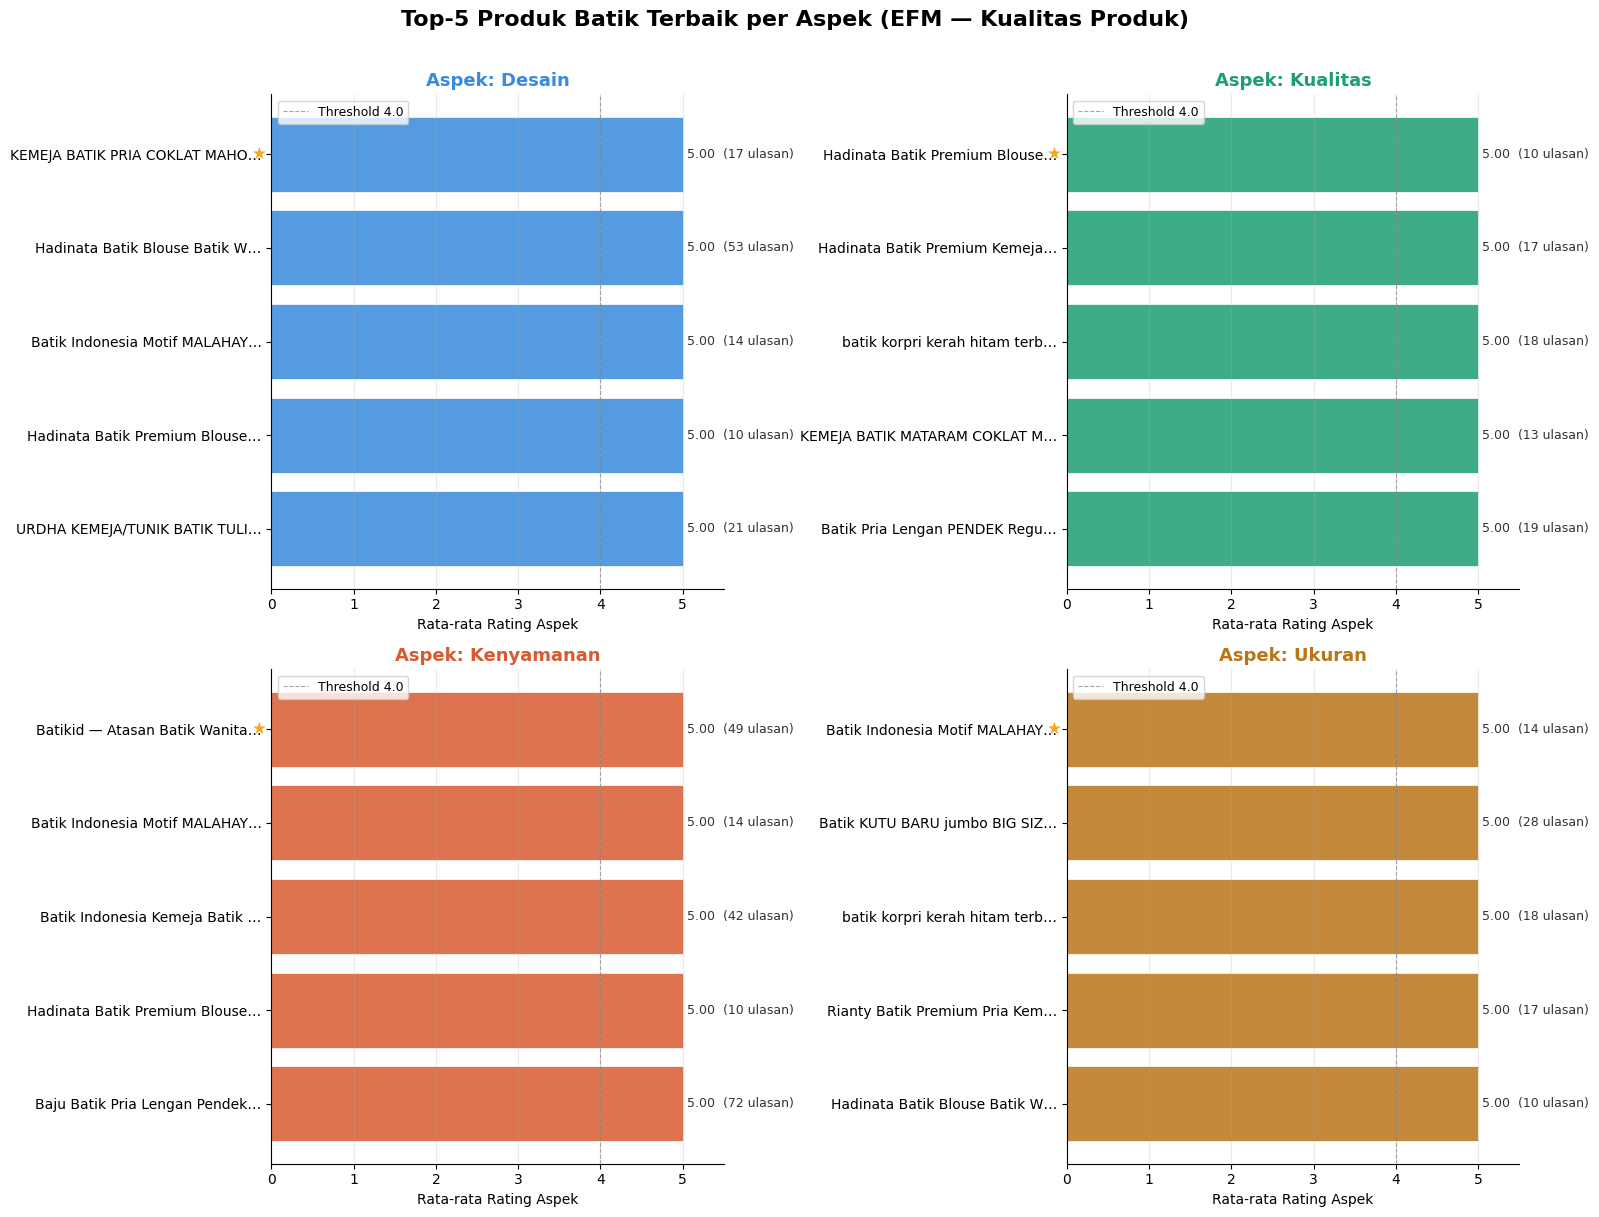

✅ Visualisasi Top-5 per Aspek tersimpan: top5_per_aspek.png


In [58]:
def shorten(name, max_len=30):
    return name if len(name) <= max_len else name[:max_len-1] + '…'

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Top-5 Produk Batik Terbaik per Aspek (EFM — Kualitas Produk)',
             fontsize=16, fontweight='bold', y=1.01)

for ax, aspek in zip(axes.flat, ASPEK_FINAL):
    color = ASPEK_COLORS[aspek]
    top5  = df_kualitas.nlargest(TOP_K, aspek)[['Product Name', aspek, 'n_ulasan']].reset_index(drop=True)
    labels = [shorten(n) for n in top5['Product Name']]
    vals   = top5[aspek].values

    bars = ax.barh(range(TOP_K), vals, color=color, alpha=0.85, edgecolor='white', linewidth=0.6)
    ax.set_yticks(range(TOP_K))
    ax.set_yticklabels(labels, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlim(0, 5.5)
    ax.set_xlabel('Rata-rata Rating Aspek', fontsize=10)
    ax.set_title(f'Aspek: {aspek}', fontsize=13, fontweight='bold', color=color)
    ax.axvline(x=4.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Threshold 4.0')
    ax.legend(fontsize=9)
    ax.grid(axis='x', alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)

    # annotasi nilai + jumlah ulasan
    for i, (bar, row) in enumerate(zip(bars, top5.itertuples())):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{getattr(row, aspek):.2f}  ({row.n_ulasan} ulasan)',
                va='center', ha='left', fontsize=9, color='#333333')
        # medali untuk rank #1
        if i == 0:
            ax.text(-0.15, bar.get_y() + bar.get_height()/2, '★',
                    va='center', ha='center', fontsize=12, color='#F5A623')

plt.tight_layout()
plt.savefig('top5_per_aspek.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisasi Top-5 per Aspek tersimpan: top5_per_aspek.png')

## 4.11.2 Radar Chart — Profil Kualitas Top-5 Produk Terbaik Keseluruhan

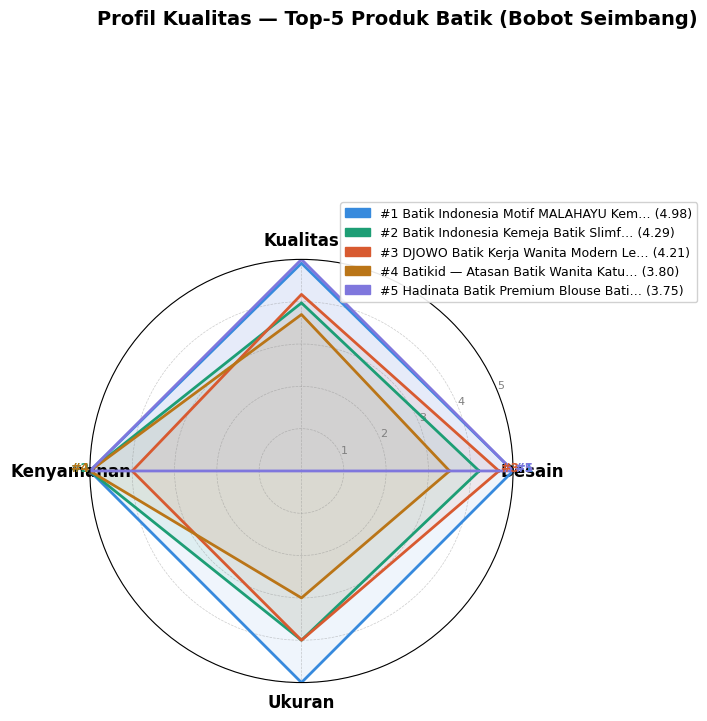

✅ Radar chart tersimpan: radar_top5.png


In [59]:
# Hitung skor EFM rata-rata (bobot aspek seimbang) untuk ranking keseluruhan
global_w = {a: 1/len(ASPEK_FINAL) for a in ASPEK_FINAL}
df_kualitas['skor_efm'] = df_kualitas[ASPEK_FINAL].apply(
    lambda row: sum(global_w[a] * row[a] for a in ASPEK_FINAL), axis=1
)
top5_overall = df_kualitas.nlargest(5, 'skor_efm').reset_index(drop=True)

# ── Radar chart ──
N = len(ASPEK_FINAL)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # tutup lingkaran

palette = ['#378ADD', '#1D9E75', '#D85A30', '#BA7517', '#7F77DD']

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.suptitle('Profil Kualitas — Top-5 Produk Batik (Bobot Seimbang)',
             fontsize=14, fontweight='bold', y=1.02)

for idx, prod in top5_overall.iterrows():
    vals = [prod[a] for a in ASPEK_FINAL] + [prod[ASPEK_FINAL[0]]]
    color = palette[idx]
    ax.plot(angles, vals, color=color, linewidth=2, linestyle='solid')
    ax.fill(angles, vals, color=color, alpha=0.08)
    # label di titik tertinggi
    max_idx = np.argmax([prod[a] for a in ASPEK_FINAL])
    ax.annotate(
        f'#{idx+1}',
        xy=(angles[max_idx], vals[max_idx]),
        xytext=(angles[max_idx], vals[max_idx] + 0.25),
        fontsize=9, color=color, fontweight='bold', ha='center'
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(ASPEK_FINAL, fontsize=12, fontweight='bold')
ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1','2','3','4','5'], fontsize=8, color='gray')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.4)

# Legenda
handles = [
    mpatches.Patch(color=palette[i],
        label=f'#{i+1} {shorten(top5_overall.loc[i,"Product Name"], 35)} ({top5_overall.loc[i,"skor_efm"]:.2f})')
    for i in range(5)
]
ax.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.45, 1.15),
          fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('radar_top5.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Radar chart tersimpan: radar_top5.png')


## 4.11.3 Heatmap Kualitas Produk per Aspek (Top-20)

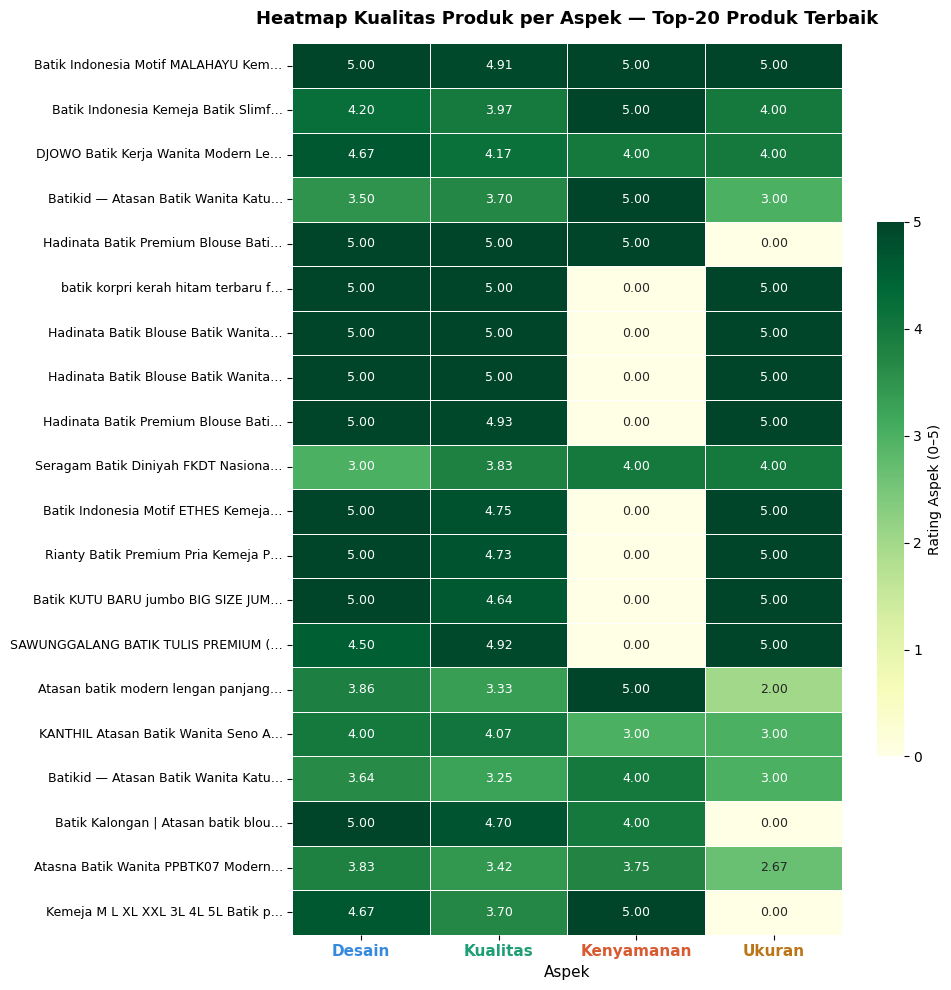

✅ Heatmap tersimpan: heatmap_kualitas.png


In [60]:
import seaborn as sns

top20 = df_kualitas.nlargest(20, 'skor_efm')[['Product Name'] + ASPEK_FINAL].copy()
top20['Product Name'] = top20['Product Name'].apply(lambda x: shorten(x, 35))
top20 = top20.set_index('Product Name')

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(
    top20,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    cmap='YlGn', vmin=0, vmax=5,
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': 'Rating Aspek (0–5)', 'shrink': 0.6},
    ax=ax
)
ax.set_title('Heatmap Kualitas Produk per Aspek — Top-20 Produk Terbaik',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Aspek', fontsize=11)
ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=11, rotation=0)
ax.tick_params(axis='y', labelsize=9)

# Warnai header kolom sesuai warna aspek
for i, aspek in enumerate(ASPEK_FINAL):
    ax.get_xticklabels()[i].set_color(ASPEK_COLORS[aspek])
    ax.get_xticklabels()[i].set_fontweight('bold')

plt.tight_layout()
plt.savefig('heatmap_kualitas.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Heatmap tersimpan: heatmap_kualitas.png')


## 4.11.4 Ringkasan Produk Terbaik per Aspek (Tabel)

In [61]:
print('=' * 75)
print(f'  RINGKASAN PRODUK TERBAIK PER ASPEK (TOP-{TOP_K})')
print('=' * 75)

for aspek in ASPEK_FINAL:
    top = df_kualitas.nlargest(TOP_K, aspek)[['Product Name', aspek, 'n_ulasan']].reset_index(drop=True)
    print(f'\n  Aspek: {aspek}')
    print(f'  {"Rank":<5} {"Nama Produk":<45} {aspek:>8}  {"Ulasan":>8}')
    print('  ' + '-' * 68)
    for i, row in top.iterrows():
        medal = ['★', '✦', '◆', '▲', '●'][i]
        print(f'  {medal} #{i+1:<3} {shorten(row["Product Name"],44):<45} {row[aspek]:>8.2f}  {row["n_ulasan"]:>8}')

print()
print('=' * 75)
print('  TOP-5 PRODUK TERBAIK KESELURUHAN (Bobot Seimbang)')
print('=' * 75)
print(f'  {"Rank":<5} {"Nama Produk":<45} {"Skor EFM":>10}  {"Ulasan":>8}')
print('  ' + '-' * 70)
for i, row in top5_overall.iterrows():
    medal = ['★', '✦', '◆', '▲', '●'][i]
    print(f'  {medal} #{i+1:<3} {shorten(row["Product Name"],44):<45} {row["skor_efm"]:>10.4f}  {row["n_ulasan"]:>8}')
print('=' * 75)
print('✅ Visualisasi Section 4.11 selesai!')


  RINGKASAN PRODUK TERBAIK PER ASPEK (TOP-5)

  Aspek: Desain
  Rank  Nama Produk                                     Desain    Ulasan
  --------------------------------------------------------------------
  ★ #1   KEMEJA BATIK PRIA COKLAT MAHOGANY LENGAN PA…      5.00        17
  ✦ #2   Hadinata Batik Blouse Batik Wanita Marion M…      5.00        53
  ◆ #3   Batik Indonesia Motif MALAHAYU Kemeja Batik…      5.00        14
  ▲ #4   Hadinata Batik Premium Blouse Batik Wanita …      5.00        10
  ● #5   URDHA KEMEJA/TUNIK BATIK TULIS PREMIUM - Ba…      5.00        21

  Aspek: Kualitas
  Rank  Nama Produk                                   Kualitas    Ulasan
  --------------------------------------------------------------------
  ★ #1   Hadinata Batik Premium Blouse Batik Wanita …      5.00        10
  ✦ #2   Hadinata Batik Premium Kemeja Batik Pria Le…      5.00        17
  ◆ #3   batik korpri kerah hitam terbaru full furin…      5.00        18
  ▲ #4   KEMEJA BATIK MATARAM COKLAT M 